In [1]:
import json
from collections.abc import Callable
from dataclasses import dataclass
from enum import Enum
from functools import lru_cache
from pathlib import Path

import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import showdown_wrapper as sdw
import torch
from scipy.spatial.distance import cdist
from scipy.special import softmax
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    pairwise_distances,
    precision_recall_fscore_support,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from umap import UMAP

from lib.dataset.queries import build_moves_table

%matplotlib inline

/nix/store/j4m2izgxkfs1fd2m7x5dy6fw8md733y0-python3-3.13.12-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

In [3]:
seed = 42

np.random.seed(seed)
rng = np.random.default_rng(seed + 1)

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PokéMaxxing - What is the ideal Pokémon?

Pokémon is a very famous game where two players let their pokémon fight in battles.
The dynamics of the battles are quite complex and each player has to choose their strategy carefully before going into a battle.

In this project I try to answer the following questions:
> If it existed a pokémon which could learn all moves, we could choose its stats, its type and its ability, what would the best choice so that that pokémon could beat as many adversaries as possible?

I intend to answer this question by training an evolutionary model, its genotype will be made of
- 4 moves within the existing ones (according to the rules, each pokémons have 4 moves available in each battle);
- 6 base statistics so that their sum is below a certain threshold:
    - Hit Points (HP)
    - Attach (ATK)
    - Defense (DEF)
    - Special Attach (SPA)
    - Special Defense (SPD)
    - Speed (SPE)
- 2 types within the existing ones (which can be the same).

Most importantly, to evaluate the fitness of each agent they will need to fight against other pokémons, so I will evolve a small MLP which will choose what to do in the fight (I will refer to it as the "battle MLP").
While the topology of the battle MLP will be fixed, the weights will evolve alongside the other genes (so no gradient descent here).

### Technical notes

Luckily, since pokémon is a very famous franchise, a lot of great tools already exist.

- I used the [PokéAPI](https://github.com/PokeAPI/pokeapi/) dataset as the main dataset for this project. This dataset is licensed under the [BSD-3-Clause License](https://github.com/PokeAPI/pokeapi/blob/master/LICENSE.md).
- The battle logic is implemented by the awesome [Pokémon Showdown](https://github.com/smogon/pokemon-showdown) library, licensed under the [MIT License](https://github.com/smogon/pokemon-showdown).

Pokémon Showdown is the most complete implementation of Pokémon battles, however it is written in TypeScript.
To use it in this project I wrote a "worker" interface to the library with the logic I need which can be controlled by piping commands through stdio.
Then I wrote a Python program which manages a pool of these NodeJS worker processes so that the decision making on which move to play is delegated to the Python code.
In this way I can execute multiple battles in parallel while still controlling everything thorugh Python.
The code for the worker and the wrapper lives in [this repository](https://github.com/billy4479/pokemon-showdown-wrapper).

While most of the code for this project is written by me, I was assisted by AI, expecially in the prototyping phase and in the parts which were not completely relevant to the evolutionary model part of the project.

### Limitations

The game of Pokémon is very complex and some parts are very much RNG based. Because of time and hardware constraints I added some rules which simplify the battle, not all of these rules are very realistic but otherwise the MLP would have had to be much bigger and the training would have been much longer.

To be precise, the battle rules that the Showdown runner is using are the following:
```ts
export const customRules = [
    "Picked Team Size = 1",
    "Max Team Size = 1",
    "Min Team Size = 1",

    "Terastal Clause",
    "Dynamax Clause",
    "Z-Move Clause",
    "CFZ Clause",

    "-Dragon Ascent",
    "-pokemontag:allitems",

    "OHKO Clause",
    "Evasion Clause",
    // "Accuracy Moves Clause",
    "Sleep Moves Clause",
    "Freeze Clause Mod",
    "Moody Clause",
    "Swagger Clause",

    "Endless Battle Clause",
    "Exact HP Mod",

    "-All Abilities",
    "+No Ability",
].join(",");
```

These limit the amout of moves each pokomon can learn and makes the battle simpler.

# Encoding moves - AutoEncoder

Our first task is kind of off topic: we need to find a way to tell the battle MLP which moves our pokémon chose to learn.
This is quite a hard task: there exist more than 900 moves in the game and each one of them is increadibly rich in information content:
they have various many numerical statistics and a lot of categorical features such as the type or the effect.

In particular the effect is problematic as they are so complicated that no dataset even attempts to describe what each effect does numerically, preferring a text description instead.

In this section I explore how to encode moves in a lower dimensional space trying to preserve meaning: moves which gets used in similar situations should be close together in the resulting embedding, so that the resulting compressed move can be fed to the MLP without blowing up the number of weights.

## Preprocessing

I started by applying some preprocessing to the moves dataset from PokéAPI, simplifying some mechanics
and removing Z-Moves as they add a non-trivial amount of complexity which is not really in the scope for this project.

After many attemps I chose to drop the `effect` column: this was just a id which could have been used to look up the effect description (in english).
There are more than 300 unique effects in the game so adding this huge one-hot encoded vector without giving any meaning to it turned out to be counterproductive:
training was focussing too much on reconstructing the effect vector correctly rather than focussing on the tactical meaning of the move.

In [4]:
moves_df = build_moves_table().drop(columns=["effect"])
moves_df["move_identifier"] = moves_df["move_identifier"].map(
    lambda x: x.replace("-", "")
)

_sd_moves = set(sdw.list_allowed_moves())
_pokeapi_moves = set(moves_df["move_identifier"])
_intersection = list(_sd_moves.intersection(_pokeapi_moves))

moves_df = moves_df[moves_df["move_identifier"].isin(_intersection)]
moves_df

,move_id,move_identifier,power,pp,accuracy,priority,effect_chance,type,damage_class,target,...,flag_snatch,flag_sound,stat_change_accuracy,stat_change_attack,stat_change_defense,stat_change_evasion,stat_change_special_attack,stat_change_special_defense,stat_change_speed,turns
0,1,pound,40,35.0,100.0,0,0.0,normal,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
4,5,megapunch,80,20.0,85.0,0,0.0,normal,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
5,6,payday,40,20.0,100.0,0,0.0,normal,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
6,7,firepunch,75,15.0,100.0,0,10.0,fire,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
7,8,icepunch,75,15.0,100.0,0,10.0,ice,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,915,temperflare,75,10.0,100.0,0,0.0,fire,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
863,916,supercellslam,100,15.0,95.0,0,0.0,electric,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
864,917,psychicnoise,75,10.0,100.0,0,0.0,psychic,special,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0
865,918,upperhand,65,15.0,100.0,3,0.0,fighting,physical,selected-pokemon,...,False,False,0,0,0,0,0,0,0,1.0


I started by reprenting this table in a way in which it can be fed to an autoencoder more easily, in particular I one-hot encoded the categorical variables.

In [5]:
metadata_cols = ["move_id", "move_identifier"]
categorical_cols = (
    moves_df.select_dtypes(include=["object"])
    .columns.drop(["move_identifier"])
    .tolist()
)

flag_cols = [col for col in moves_df.columns if col.startswith("flag_")]
stat_change_cols = [
    col for col in moves_df.columns if col.startswith("stat_change_")
]

numeric_cols = [
    col
    for col in moves_df.columns
    if col
    not in metadata_cols + categorical_cols + flag_cols + stat_change_cols
    and pd.api.types.is_numeric_dtype(moves_df[col])
]

{
    "metadata": metadata_cols,
    "categorical": categorical_cols,
    "flags": flag_cols,
    "numeric": numeric_cols,
    "stat_change": stat_change_cols,
}

{'metadata': ['move_id', 'move_identifier'],
 'categorical': ['type',
  'damage_class',
  'target',
  'meta_ailment',
  'meta_category'],
 'flags': ['flag_authentic',
  'flag_ballistics',
  'flag_bite',
  'flag_charge',
  'flag_contact',
  'flag_dance',
  'flag_defrost',
  'flag_distance',
  'flag_gravity',
  'flag_heal',
  'flag_mental',
  'flag_mirror',
  'flag_non_sky_battle',
  'flag_powder',
  'flag_protect',
  'flag_pulse',
  'flag_punch',
  'flag_recharge',
  'flag_reflectable',
  'flag_snatch',
  'flag_sound'],
 'numeric': ['power',
  'pp',
  'accuracy',
  'priority',
  'effect_chance',
  'drain',
  'healing',
  'crit_rate',
  'ailment_chance',
  'flinch_chance',
  'stat_chance',
  'turns'],
 'stat_change': ['stat_change_accuracy',
  'stat_change_attack',
  'stat_change_defense',
  'stat_change_evasion',
  'stat_change_special_attack',
  'stat_change_special_defense',
  'stat_change_speed']}

In [6]:
numeric_df = moves_df[numeric_cols].astype(np.float32)
numeric_mean = numeric_df.mean(axis=0)
numeric_std = numeric_df.std(axis=0, ddof=0).replace(0.0, 1.0)
numeric_scaled_df = ((numeric_df - numeric_mean) / numeric_std).astype(
    np.float32
)

In [7]:
categorical_df = pd.get_dummies(
    moves_df[categorical_cols].astype("category"),
    prefix=categorical_cols,
    dtype=np.float32,
)

In [8]:
flags_df = moves_df[flag_cols].astype(np.float32)

In [9]:
stat_change_df = moves_df[stat_change_cols].astype(np.float32)

In [10]:
feature_df = pd.concat(
    [
        numeric_scaled_df,
        stat_change_df,
        categorical_df,
        flags_df,
    ],
    axis=1,
)

feature_df.shape

(671, 106)

In [11]:
feature_blocks = {
    "numeric": numeric_scaled_df.columns.tolist(),
    "stat_change": stat_change_df.columns.tolist(),
    "categorical": categorical_df.columns.tolist(),
    "flags": flags_df.columns.tolist(),
}

feature_groups = {}
start = 0
for group_name, columns in feature_blocks.items():
    end = start + len(columns)
    feature_groups[group_name] = {
        "columns": columns,
        "slice": slice(start, end),
        "size": len(columns),
    }
    start = end

assert start == feature_df.shape[1]

column_to_index = {
    column: index for index, column in enumerate(feature_df.columns)
}

categorical_feature_groups = {}
for categorical_col in categorical_cols:
    dummy_columns = [
        column
        for column in categorical_df.columns
        if column.startswith(f"{categorical_col}_")
    ]

    categorical_feature_groups[categorical_col] = {
        "columns": dummy_columns,
        "indices": [column_to_index[column] for column in dummy_columns],
        "size": len(dummy_columns),
    }

group_loss_weights = {
    "numeric": 1.0,
    "stat_change": 1.0,
    "categorical": 1.0,
    "flags": 2.5,
}

{
    "feature_groups": {
        group_name: group["size"]
        for group_name, group in feature_groups.items()
    },
    "categorical_feature_groups": {
        group_name: group["size"]
        for group_name, group in categorical_feature_groups.items()
    },
    "group_loss_weights": group_loss_weights,
}

{'feature_groups': {'numeric': 12,
  'stat_change': 7,
  'categorical': 66,
  'flags': 21},
 'categorical_feature_groups': {'type': 18,
  'damage_class': 3,
  'target': 15,
  'meta_ailment': 17,
  'meta_category': 13},
 'group_loss_weights': {'numeric': 1.0,
  'stat_change': 1.0,
  'categorical': 1.0,
  'flags': 2.5}}

## The model

The actual autoencoder is quite small, just two layers with not many dimensions and, in particular, a very small latent space.

This choice was made so that the battle MLP
(which will be also very tiny since I won't be able to train it with gradient descent)
doesn't need much "effort" to decode what a move actually does.

I'm not interesed in the model generalizing, it is fine if it overfits since the moves it will have to encode are always the same,
however I decided to include a `Dropout`: this will make the decode "dumber" which should match the battle MLP which will indeed will also be not very smart.

In [12]:
class MoveAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dims=(256, 128)):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.SiLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.SiLU(),
            nn.Linear(hidden_dims[1], latent_dim),
            nn.LayerNorm(latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Dropout(p=0.1),
            nn.Linear(latent_dim, hidden_dims[1]),
            nn.SiLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.SiLU(),
            nn.Linear(hidden_dims[0], input_dim),
        )

    def encode(self, _inputs):
        return self.encoder(_inputs)

    def decode(self, _latent):
        return self.decoder(_latent)

    def forward(self, _inputs):
        _latent = self.encode(_inputs)
        _reconstruction_logits = self.decode(_latent)
        return _reconstruction_logits, _latent


def _zero_like_loss(inputs):
    return inputs.sum() * 0.0


def _mse_group_loss(reconstruction_logits, inputs, group_name):
    group_slice = feature_groups[group_name]["slice"]

    if feature_groups[group_name]["size"] == 0:
        return _zero_like_loss(inputs)

    return F.mse_loss(
        reconstruction_logits[:, group_slice],
        inputs[:, group_slice],
        reduction="mean",
    )


def _bce_group_loss(reconstruction_logits, inputs, group_name):
    group_slice = feature_groups[group_name]["slice"]

    if feature_groups[group_name]["size"] == 0:
        return _zero_like_loss(inputs)

    return F.binary_cross_entropy_with_logits(
        reconstruction_logits[:, group_slice],
        inputs[:, group_slice],
        reduction="mean",
    )


def _categorical_grouped_cross_entropy_loss(reconstruction_logits, inputs):
    categorical_losses = []

    for categorical_group in categorical_feature_groups.values():
        indices = categorical_group["indices"]

        if len(indices) <= 1:
            continue

        group_logits = reconstruction_logits[:, indices]
        target_classes = inputs[:, indices].argmax(dim=1)

        categorical_losses.append(
            F.cross_entropy(
                group_logits,
                target_classes,
                reduction="mean",
            )
        )

    if len(categorical_losses) == 0:
        return _zero_like_loss(inputs)

    return torch.stack(categorical_losses).mean()


def ae_loss(
    reconstruction_logits,
    inputs,
    weights=None,
):
    if weights is None:
        weights = group_loss_weights

    recon_numeric = _mse_group_loss(
        reconstruction_logits,
        inputs,
        "numeric",
    )

    recon_stat_change = _mse_group_loss(
        reconstruction_logits,
        inputs,
        "stat_change",
    )

    recon_categorical = _categorical_grouped_cross_entropy_loss(
        reconstruction_logits,
        inputs,
    )

    recon_flags = _bce_group_loss(
        reconstruction_logits,
        inputs,
        "flags",
    )

    loss_parts = {
        "recon_numeric": recon_numeric,
        "recon_stat_change": recon_stat_change,
        "recon_categorical": recon_categorical,
        "recon_flags": recon_flags,
    }

    total = (
        weights["numeric"] * recon_numeric
        + weights["stat_change"] * recon_stat_change
        + weights["categorical"] * recon_categorical
        + weights["flags"] * recon_flags
    )

    return total, loss_parts

### Training

Since the move table is finite and the autoencoder is used as a preprocessing step,
I evaluate reconstruction quality on the full dataset rather than using a train/validation split.

In [13]:
def train(
    dataset: pd.DataFrame,
    latent_dim: int,
    epochs: int,
    loss_weights,
    learning_rate: float = 1e-4,
    use_cache=False,
):
    batch_size = 128
    cache_path = "move_autoencoder.pt"

    x = torch.tensor(dataset.to_numpy(), dtype=torch.float32)
    tensor_dataset = TensorDataset(x)
    dataloader = DataLoader(
        tensor_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    input_dim = x.shape[1]
    dataset_size = len(tensor_dataset)

    model = MoveAutoencoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
    ).to(device)

    using_cache = False

    if use_cache and Path(cache_path).exists():
        model.load_state_dict(
            torch.load(cache_path, map_location=device, weights_only=True)
        )
        using_cache = True
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=5e-3,
        )

        history_rows = []
        epoch_progress = tqdm(
            range(1, epochs + 1),
            desc="Training AE",
            unit="epoch",
        )

        for epoch in epoch_progress:
            model.train()

            epoch_totals = {
                "loss": 0.0,
                "recon_numeric": 0.0,
                "recon_stat_change": 0.0,
                "recon_categorical": 0.0,
                "recon_flags": 0.0,
            }

            for (batch,) in dataloader:
                batch = batch.to(device)

                optimizer.zero_grad()

                reconstruction_logits_batch, latent_batch = model(batch)

                loss, loss_parts = ae_loss(
                    reconstruction_logits_batch,
                    batch,
                    weights=loss_weights,
                )

                loss.backward()
                optimizer.step()

                batch_count = batch.shape[0]

                epoch_totals["loss"] += loss.item() * batch_count
                for loss_name, loss_value in loss_parts.items():
                    epoch_totals[loss_name] += loss_value.item() * batch_count

            history_row = {
                "epoch": epoch,
                **{
                    key: value / dataset_size
                    for key, value in epoch_totals.items()
                },
            }

            history_rows.append(history_row)

            epoch_progress.set_postfix(
                loss=f"{history_row['loss']:.4f}",
                num=f"{history_row['recon_numeric']:.4f}",
                stat=f"{history_row['recon_stat_change']:.4f}",
                cat=f"{history_row['recon_categorical']:.4f}",
                flags=f"{history_row['recon_flags']:.4f}",
            )

        torch.save(model.state_dict(), cache_path)

    model.eval()
    with torch.no_grad():
        x_device = x.to(device)
        latent_embedding = model.encode(x_device)
        reconstruction_logits_eval = model.decode(latent_embedding)

    embedding_matrix = latent_embedding.detach().cpu().numpy()
    reconstruction_logits_matrix = (
        reconstruction_logits_eval.detach().cpu().numpy()
    )

    return (
        model,
        embedding_matrix,
        reconstruction_logits_matrix,
        pd.DataFrame(history_rows) if not using_cache else None,
    )

In [14]:
(
    move_autoencoder,
    embedding_matrix,
    reconstruction_logits_matrix,
    training_history,
) = train(
    feature_df,
    latent_dim=8,
    epochs=2**10,
    loss_weights=group_loss_weights,
)

if training_history is None:
    print("Weights loaded from cache.")

Training AE: 100%|████████████████████| 1024/1024 [01:04<00:00, 15.81epoch/s, cat=0.2640, flags=0.0472, loss=0.6200, num=0.1956, stat=0.0423]


In [15]:
def get_training_summary():
    if training_history is None:
        return None

    final_training_row = training_history.iloc[-1]

    return {
        "device": str(device),
        "epochs": int(training_history["epoch"].max()),
        "final_loss": float(final_training_row["loss"]),
        "best_loss": float(training_history["loss"].min()),
        "final_recon_numeric": float(final_training_row["recon_numeric"]),
        "final_recon_stat_change": float(
            final_training_row["recon_stat_change"]
        ),
        "final_recon_categorical": float(
            final_training_row["recon_categorical"]
        ),
        "final_recon_flags": float(final_training_row["recon_flags"]),
    }


get_training_summary()

{'device': 'cpu',
 'epochs': 1024,
 'final_loss': 0.619990023433185,
 'best_loss': 0.5736203780828041,
 'final_recon_numeric': 0.19564104797499013,
 'final_recon_stat_change': 0.042262714211835944,
 'final_recon_categorical': 0.26398292732398665,
 'final_recon_flags': 0.04724132837019805}

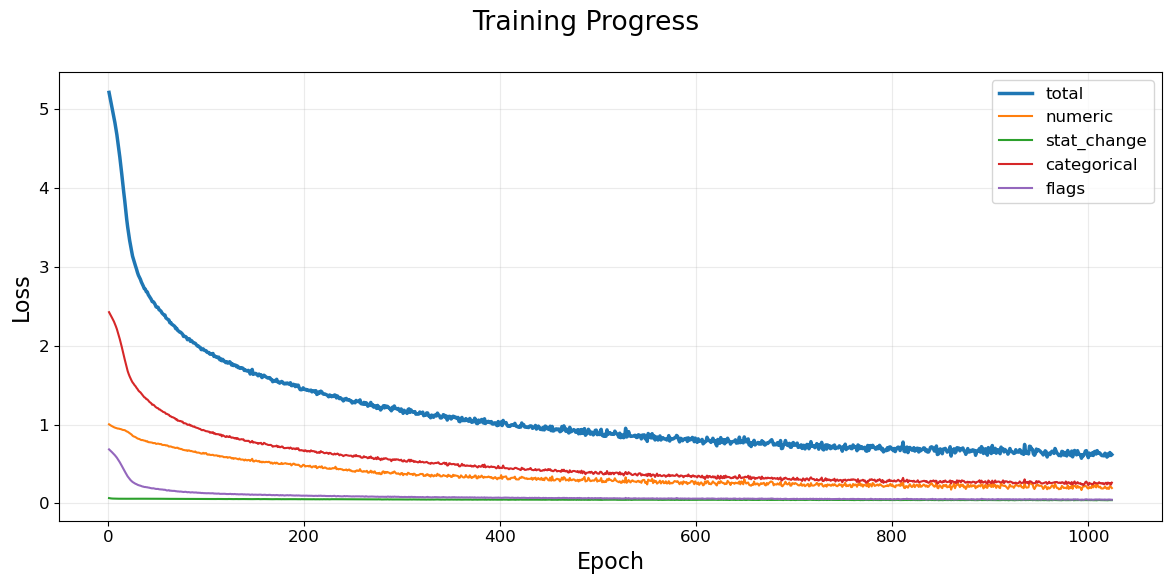

In [16]:
def plot_training():
    if training_history is None:
        return

    fig, ax = plt.subplots()

    ax.plot(
        training_history["epoch"],
        training_history["loss"],
        label="total",
        linewidth=2.5,
    )

    ax.plot(
        training_history["epoch"],
        training_history["recon_numeric"],
        label="numeric",
        linewidth=1.5,
    )

    ax.plot(
        training_history["epoch"],
        training_history["recon_stat_change"],
        label="stat_change",
        linewidth=1.5,
    )

    ax.plot(
        training_history["epoch"],
        training_history["recon_categorical"],
        label="categorical",
        linewidth=1.5,
    )

    ax.plot(
        training_history["epoch"],
        training_history["recon_flags"],
        label="flags",
        linewidth=1.5,
    )

    fig.suptitle("Training Progress")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()

plot_training()

### On the choice of hyperparameters

- The learning rate was made low and the number of epochs high as we don't care if the autoencoder overfits or if the training takes longer, we just want the best result with the least possible number of dimensions in the latent space.
- Flags used to have a worse reconstruction than other parameters, so I bumped their loss weight so that the model would optimize for them more aggressively.
- I experimented a lot with the dimension of the latent space. It seems like a higher number of dimensions may help when the number of epochs is low, however with enough training the reconstruction is fine even with as little as 8 dimensions. Lower than 8 we start losing some structure, but I will comment on this again later in the clustering section.

## Reconstruction evaluation

These metrics should be read as compression diagnostics:
they tell us how much information is preserved by the latent representation.

Different feature families need different metrics:

- numeric values and raw stat-change magnitudes use regression metrics;
- true categorical variables use grouped multiclass accuracy;
- flags use binary classification metrics;
- stat-change-by-target flags use binary metrics plus exact-match accuracy.

Note that we are not just interested to how well the data compresses and gets reconstructed, but also if the latent space carries geometrical information about the tactical meaning of the move.

In [17]:
reconstruction_logits_df = pd.DataFrame(
    reconstruction_logits_matrix,
    columns=feature_df.columns,
    index=feature_df.index,
)

reconstruction_probability_df = pd.DataFrame(
    1.0 / (1.0 + np.exp(-reconstruction_logits_matrix)),
    columns=feature_df.columns,
    index=feature_df.index,
)


def _safe_binary_metrics(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true.reshape(-1),
        y_pred.reshape(-1),
        average="binary",
        zero_division=0,
    )

    accuracy = float((y_true == y_pred).mean())

    return {
        "accuracy": accuracy,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "support": int(y_true.sum()),
    }


def evaluate_numeric_group(group_name):
    group_slice = feature_groups[group_name]["slice"]
    group_columns = feature_groups[group_name]["columns"]

    y_true = feature_df.iloc[:, group_slice].to_numpy()
    y_pred = reconstruction_logits_df.iloc[:, group_slice].to_numpy()

    errors = y_pred - y_true

    summary = {
        "mae": float(np.abs(errors).mean()),
        "rmse": float(np.sqrt((errors**2).mean())),
    }

    per_column = pd.DataFrame(
        {
            "column": group_columns,
            "mae": np.abs(errors).mean(axis=0),
            "rmse": np.sqrt((errors**2).mean(axis=0)),
        }
    ).sort_values("mae", ascending=False)

    return summary, per_column


def evaluate_categorical_groups():
    rows = []

    for (
        categorical_name,
        categorical_group,
    ) in categorical_feature_groups.items():
        indices = categorical_group["indices"]

        if len(indices) <= 1:
            continue

        true_class = feature_df.iloc[:, indices].to_numpy().argmax(axis=1)
        pred_class = (
            reconstruction_logits_df.iloc[:, indices].to_numpy().argmax(axis=1)
        )

        rows.append(
            {
                "categorical": categorical_name,
                "n_classes": len(indices),
                "accuracy": float((true_class == pred_class).mean()),
            }
        )

    per_categorical = pd.DataFrame(rows).sort_values(
        "accuracy",
        ascending=True,
    )

    summary = {
        "mean_accuracy": float(per_categorical["accuracy"].mean()),
        "min_accuracy": float(per_categorical["accuracy"].min()),
    }

    return summary, per_categorical


def evaluate_binary_group(group_name):
    group_slice = feature_groups[group_name]["slice"]
    group_columns = feature_groups[group_name]["columns"]

    y_true = feature_df.iloc[:, group_slice].to_numpy().astype(bool)
    y_pred = (
        reconstruction_probability_df.iloc[:, group_slice].to_numpy() >= 0.5
    )

    micro = _safe_binary_metrics(y_true, y_pred)

    rows = []
    for column_index, column in enumerate(group_columns):
        column_metrics = _safe_binary_metrics(
            y_true[:, column_index],
            y_pred[:, column_index],
        )
        rows.append(
            {
                "column": column,
                **column_metrics,
            }
        )

    per_column = pd.DataFrame(rows).sort_values("f1", ascending=True)

    summary = {
        "accuracy": micro["accuracy"],
        "precision": micro["precision"],
        "recall": micro["recall"],
        "micro_f1": micro["f1"],
        "macro_f1": float(per_column["f1"].mean()),
    }

    return summary, per_column

In [18]:
numeric_summary, numeric_eval_by_column = evaluate_numeric_group("numeric")
stat_change_summary, stat_change_eval_by_column = evaluate_numeric_group(
    "stat_change"
)

categorical_summary, categorical_eval_by_group = evaluate_categorical_groups()

flags_summary, flags_eval_by_column = evaluate_binary_group("flags")

reconstruction_summary = pd.DataFrame(
    [
        {
            "group": "numeric",
            "metric": "mae_scaled",
            "value": numeric_summary["mae"],
        },
        {
            "group": "numeric",
            "metric": "rmse_scaled",
            "value": numeric_summary["rmse"],
        },
        {
            "group": "stat_change",
            "metric": "mae",
            "value": stat_change_summary["mae"],
        },
        {
            "group": "stat_change",
            "metric": "rmse",
            "value": stat_change_summary["rmse"],
        },
        {
            "group": "categorical",
            "metric": "mean_accuracy",
            "value": categorical_summary["mean_accuracy"],
        },
        {
            "group": "flags",
            "metric": "macro_f1",
            "value": flags_summary["macro_f1"],
        },
        {
            "group": "flags",
            "metric": "micro_f1",
            "value": flags_summary["micro_f1"],
        },
    ]
)

reconstruction_summary

,group,metric,value
0,numeric,mae_scaled,0.187053
1,numeric,rmse_scaled,0.330782
2,stat_change,mae,0.086142
3,stat_change,rmse,0.192971
4,categorical,mean_accuracy,0.976453
5,flags,macro_f1,0.611752
6,flags,micro_f1,0.946012


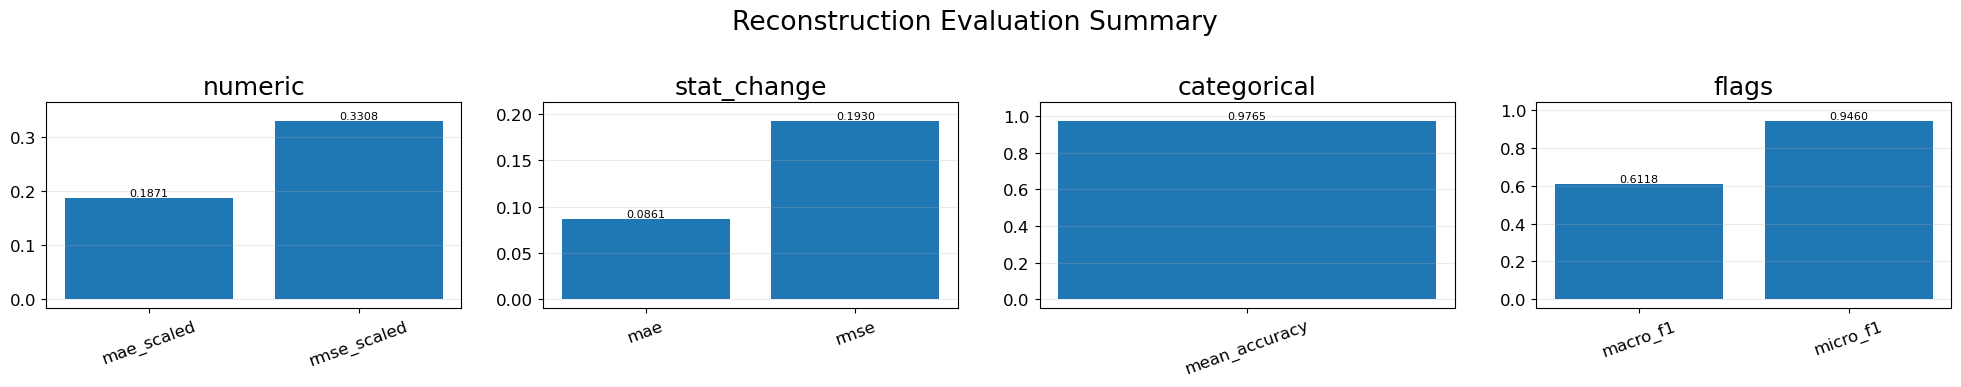

In [19]:
_plot_df = reconstruction_summary.copy()

_direction_map = {
    "mae_scaled": "lower is better",
    "rmse_scaled": "lower is better",
    "mae": "lower is better",
    "rmse": "lower is better",
    "mean_accuracy": "higher is better",
    "macro_f1": "higher is better",
    "micro_f1": "higher is better",
}

_groups = _plot_df["group"].unique()

_fig, _axes = plt.subplots(
    1, len(_groups), figsize=(5 * len(_groups), 4), sharey=False
)

for _ax, _group in zip(_axes, _groups):
    _group_df = _plot_df[_plot_df["group"] == _group]
    _labels = _group_df["metric"].values
    _values = _group_df["value"].values
    _direction = _direction_map[_labels[0]]

    _bars = _ax.bar(_labels, _values)
    _ax.set_title(_group)
    _ax.tick_params(axis="x", rotation=20)
    _ax.grid(axis="y", alpha=0.25)

    _ymin, _ymax = _ax.get_ylim()
    _y_range = _ymax - _ymin
    _ax.set_ylim(_ymin - 0.05 * _y_range, _ymax + 0.05 * _y_range)

    for _bar, _val in zip(_bars, _values):
        _ax.text(
            _bar.get_x() + _bar.get_width() / 2,
            _bar.get_height(),
            f"{_val:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

_fig.suptitle("Reconstruction Evaluation Summary")
_fig.tight_layout()

In [20]:
numeric_eval_by_column

,column,mae,rmse
1,pp,0.392917,0.506583
2,accuracy,0.325771,0.485080
0,power,0.294533,0.418322
3,priority,0.207627,0.369326
7,crit_rate,0.152584,0.284799
9,flinch_chance,0.148568,0.326129
5,drain,0.147366,0.264688
4,effect_chance,0.126251,0.189596
11,turns,0.123312,0.289384
8,ailment_chance,0.118668,0.213731


In [21]:
stat_change_eval_by_column

,column,mae,rmse
4,stat_change_special_attack,0.118097,0.248800
2,stat_change_defense,0.105238,0.211298
1,stat_change_attack,0.103079,0.213193
6,stat_change_speed,0.099230,0.221429
5,stat_change_special_defense,0.098377,0.207269
0,stat_change_accuracy,0.044980,0.100226
3,stat_change_evasion,0.033991,0.081424


In [22]:
categorical_eval_by_group

,categorical,n_classes,accuracy
0,type,18,0.900149
2,target,15,0.985097
1,damage_class,3,0.997019
3,meta_ailment,17,1.000000
4,meta_category,13,1.000000


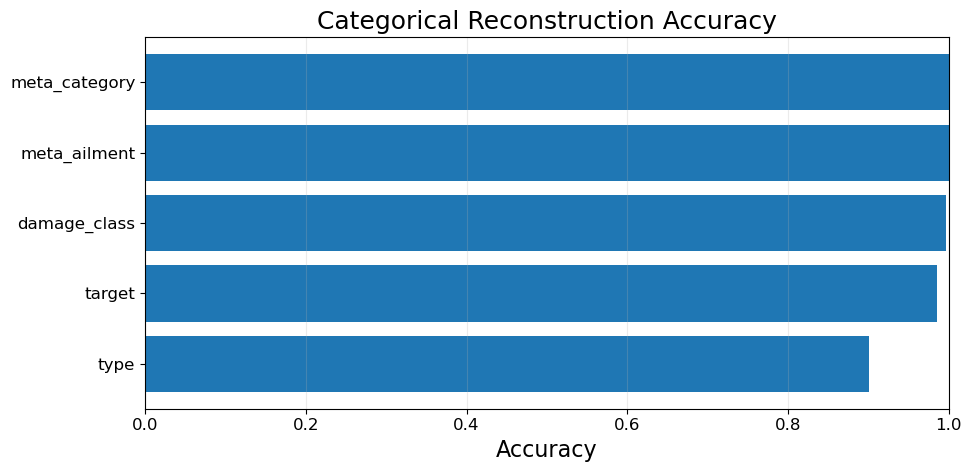

In [23]:
_plot_df = categorical_eval_by_group.sort_values(
    "accuracy",
    ascending=True,
)

_fig, _ax = plt.subplots(figsize=(10, 5))

_ax.barh(
    _plot_df["categorical"],
    _plot_df["accuracy"],
)

_ax.set_title("Categorical Reconstruction Accuracy")
_ax.set_xlabel("Accuracy")
_ax.set_xlim(0.0, 1.0)
_ax.grid(axis="x", alpha=0.25)

_fig.tight_layout()

In [24]:
flags_eval_by_column

,column,accuracy,precision,recall,f1,support
3,flag_charge,0.982116,0.000000,0.000000,0.000000,12
2,flag_bite,0.988077,0.000000,0.000000,0.000000,8
5,flag_dance,0.985097,0.000000,0.000000,0.000000,10
8,flag_gravity,0.991058,0.000000,0.000000,0.000000,6
1,flag_ballistics,0.974665,1.000000,0.055556,0.105263,18
12,flag_non_sky_battle,0.961252,1.000000,0.133333,0.235294,30
15,flag_pulse,0.992548,1.000000,0.285714,0.444444,7
13,flag_powder,0.994039,0.666667,0.400000,0.500000,5
16,flag_punch,0.986587,1.000000,0.400000,0.571429,15
6,flag_defrost,0.992548,0.714286,0.625000,0.666667,8


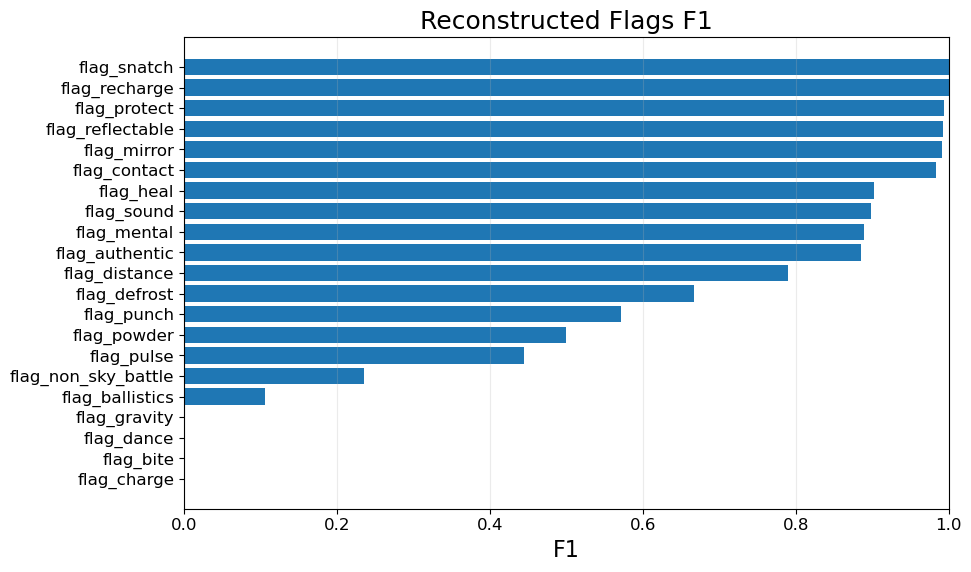

In [25]:
_plot_df = flags_eval_by_column.sort_values(
    "f1",
    ascending=True,
)

_fig, _ax = plt.subplots(figsize=(10, 6))

_ax.barh(
    _plot_df["column"],
    _plot_df["f1"],
)

_ax.set_title("Reconstructed Flags F1")
_ax.set_xlabel("F1")
_ax.set_xlim(0.0, 1.0)
_ax.grid(axis="x", alpha=0.25)

_fig.tight_layout()

### Understanding the structure of the latent space

Even if the reconstruction accuracy is good it doesn't mean that the latent space is in a good shape for the battle MLP.

I tried plotting some UMAPs and PCAs and some clustering algorithms.

In [26]:
def compute_umap_pca(embedding_matrix, n_components=2):
    umap = UMAP(
        random_state=seed,
        n_neighbors=10,
        min_dist=0.75,
        metric="euclidean",
        n_jobs=1,
        n_components=n_components,
    ).fit_transform(embedding_matrix)
    pca = PCA(n_components=n_components).fit_transform(embedding_matrix)
    return (umap.T, pca.T)

In [27]:
def plot_umap_pca_2d(
    umap, pca, labels, get_mask, title, legend_title="", legend=True
):
    fig, (ax1, ax2) = plt.subplots(1, 2)

    fig.suptitle(title)
    fig.tight_layout()

    cmap = plt.get_cmap("tab20")
    colors_per_label = {
        label: cmap(i % cmap.N) for i, label in enumerate(labels)
    }

    def scatter(ax, data):
        ax.grid(alpha=0.25)

        for label in labels:
            mask = get_mask(label)
            ax.scatter(
                data[0, mask],
                data[1, mask],
                s=10,
                alpha=0.7,
                color=colors_per_label[label],
                label=label,
            )

    ax1.set_title("UMAP")
    scatter(ax1, umap)

    ax2.set_title("PCA")
    scatter(ax2, pca)

    if legend:
        ax2.legend(title=legend_title, ncols=2, loc="lower right")

In [28]:
umap, pca = compute_umap_pca(embedding_matrix)

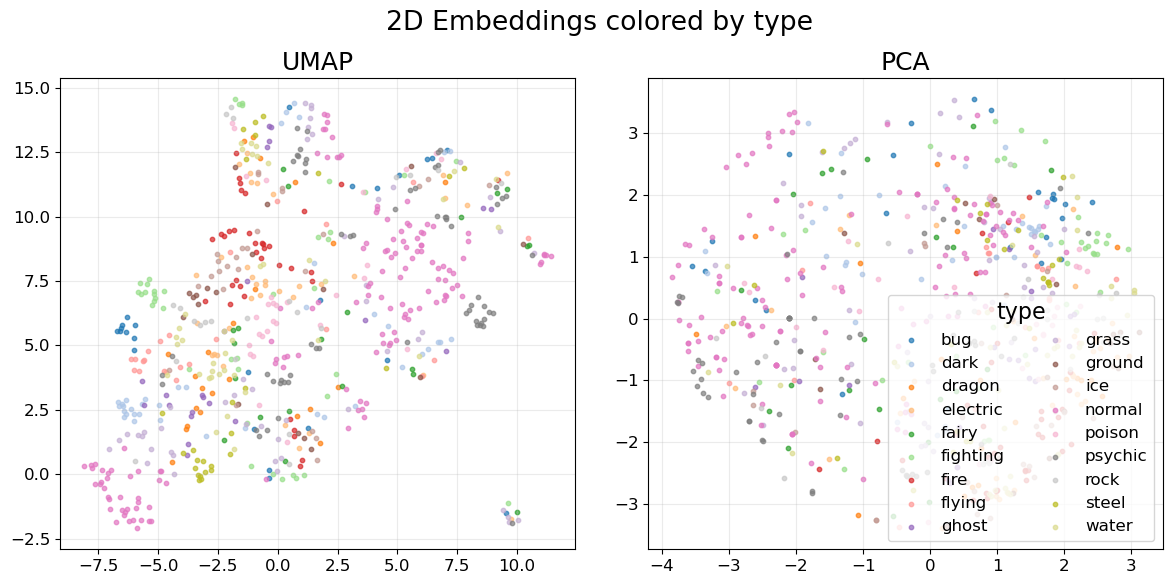

In [29]:
types_unique = moves_df["type"].unique().tolist()
types_unique.sort()

plot_umap_pca_2d(
    umap,
    pca,
    types_unique,
    lambda type: moves_df["type"] == type,
    "2D Embeddings colored by type",
    "type",
)

In [30]:
def best_kmeans_silhouette(data, max_k):
    data = StandardScaler().fit_transform(data)
    best_score = -float("inf")
    best_labels = None
    best_k = 0
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=seed)
        labels = kmeans.fit_predict(data)
        score = silhouette_score(data, labels)
        if score > best_score:
            best_score = score
            best_labels = labels
            best_k = k

            print(f"k: {k} -> {best_score}")

    return best_labels, best_k

k: 2 -> 0.18193891644477844
k: 5 -> 0.18965405225753784
k: 6 -> 0.1940881609916687
k: 7 -> 0.2052416354417801
k: 9 -> 0.21223731338977814
k: 21 -> 0.21550700068473816
k: 24 -> 0.2189382165670395
k: 25 -> 0.21901878714561462
k: 26 -> 0.224509596824646
k: 39 -> 0.22475531697273254
k: 40 -> 0.2249278724193573
k: 41 -> 0.22930315136909485
k: 43 -> 0.23240186274051666
k: 44 -> 0.23755180835723877
k: 45 -> 0.2379963994026184
k: 46 -> 0.24001094698905945
k: 47 -> 0.24140693247318268
k: 50 -> 0.24631771445274353
k: 51 -> 0.2477155476808548
k: 55 -> 0.25519898533821106
k: 56 -> 0.2567690908908844
k: 58 -> 0.2591625154018402
k: 62 -> 0.2604433596134186


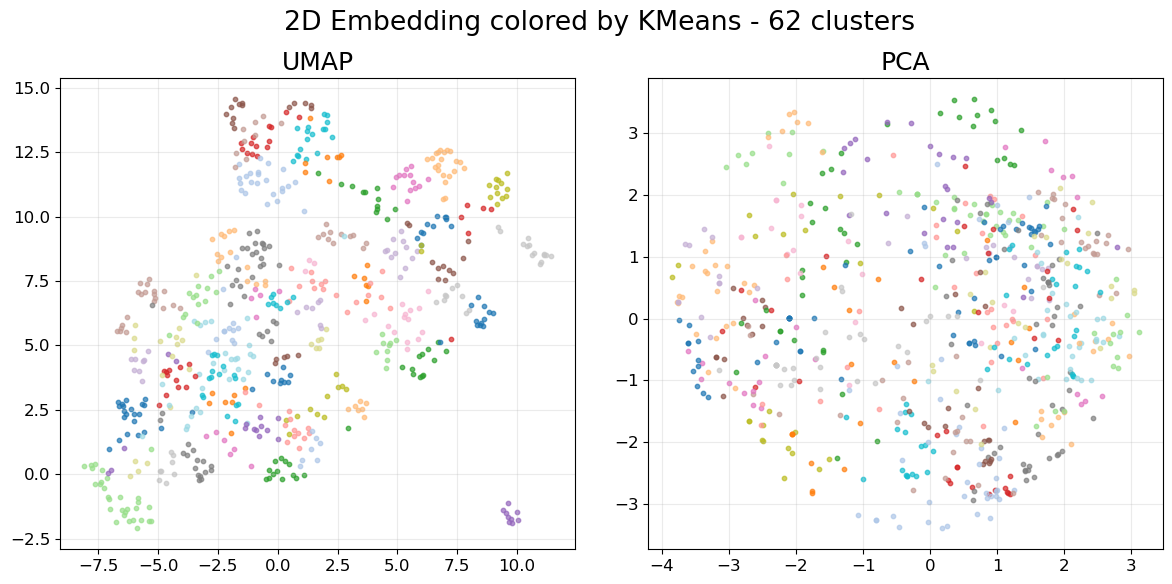

In [31]:
kmeans_labels, k = best_kmeans_silhouette(embedding_matrix, max_k=64)
plot_umap_pca_2d(
    umap,
    pca,
    list(range(k)),
    lambda label: kmeans_labels == label,
    f"2D Embedding colored by KMeans - {k} clusters",
    legend=False,
)

In [32]:
umap_3, pca_3 = compute_umap_pca(embedding_matrix, n_components=3)

In [33]:
def plot_embedding_3d(embedding_3, labels, title: str):
    import plotly.graph_objects as go

    df = pd.DataFrame(
        {
            "UMAP1": embedding_3[0],
            "UMAP2": embedding_3[1],
            "UMAP3": embedding_3[2],
            "cluster": labels,
        }
    )

    fig = go.Figure()

    # Normal clusters
    clustered = df[df.cluster != -1]

    for c in sorted(clustered.cluster.unique()):
        sub = clustered[clustered.cluster == c]

        fig.add_trace(
            go.Scatter3d(
                x=sub.UMAP1,
                y=sub.UMAP2,
                z=sub.UMAP3,
                mode="markers",
                name=f"cluster {c}",
                marker=dict(size=2, opacity=0.8),
            )
        )

    # Noise / outliers
    noise = df[df.cluster == -1]

    fig.add_trace(
        go.Scatter3d(
            x=noise.UMAP1,
            y=noise.UMAP2,
            z=noise.UMAP3,
            mode="markers",
            name="noise",
            marker=dict(
                size=1,
                color="lightgray",
                opacity=0.7,
            ),
        )
    )

    fig.update_layout(
        title=title,
        width=1000,
        height=800,
    )

    fig.show()

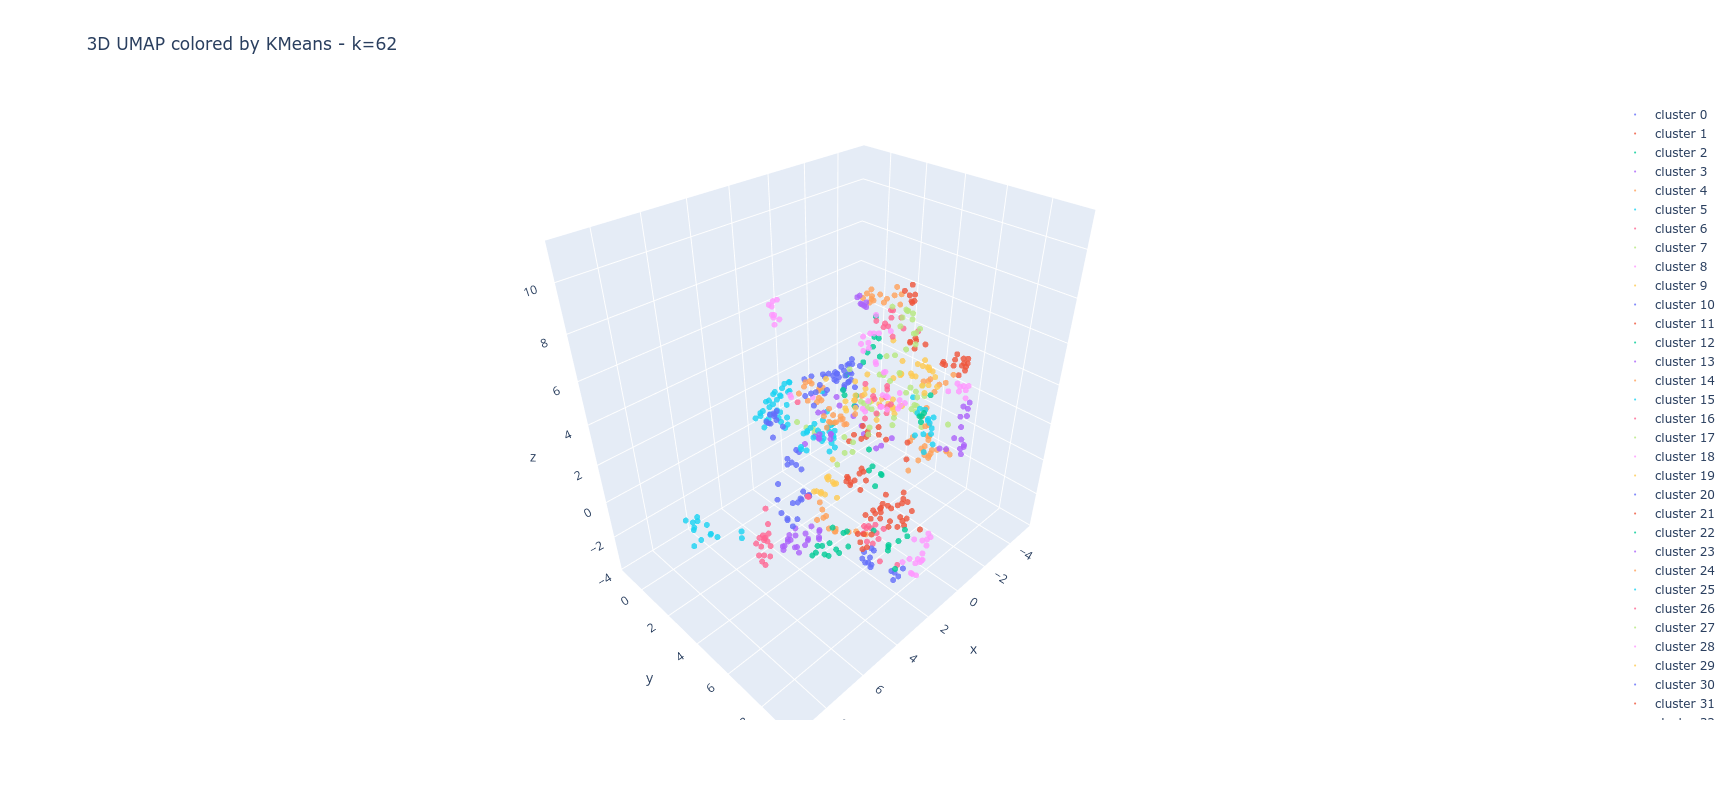

In [34]:
plot_embedding_3d(umap_3, kmeans_labels, f"3D UMAP colored by KMeans - k={k}")

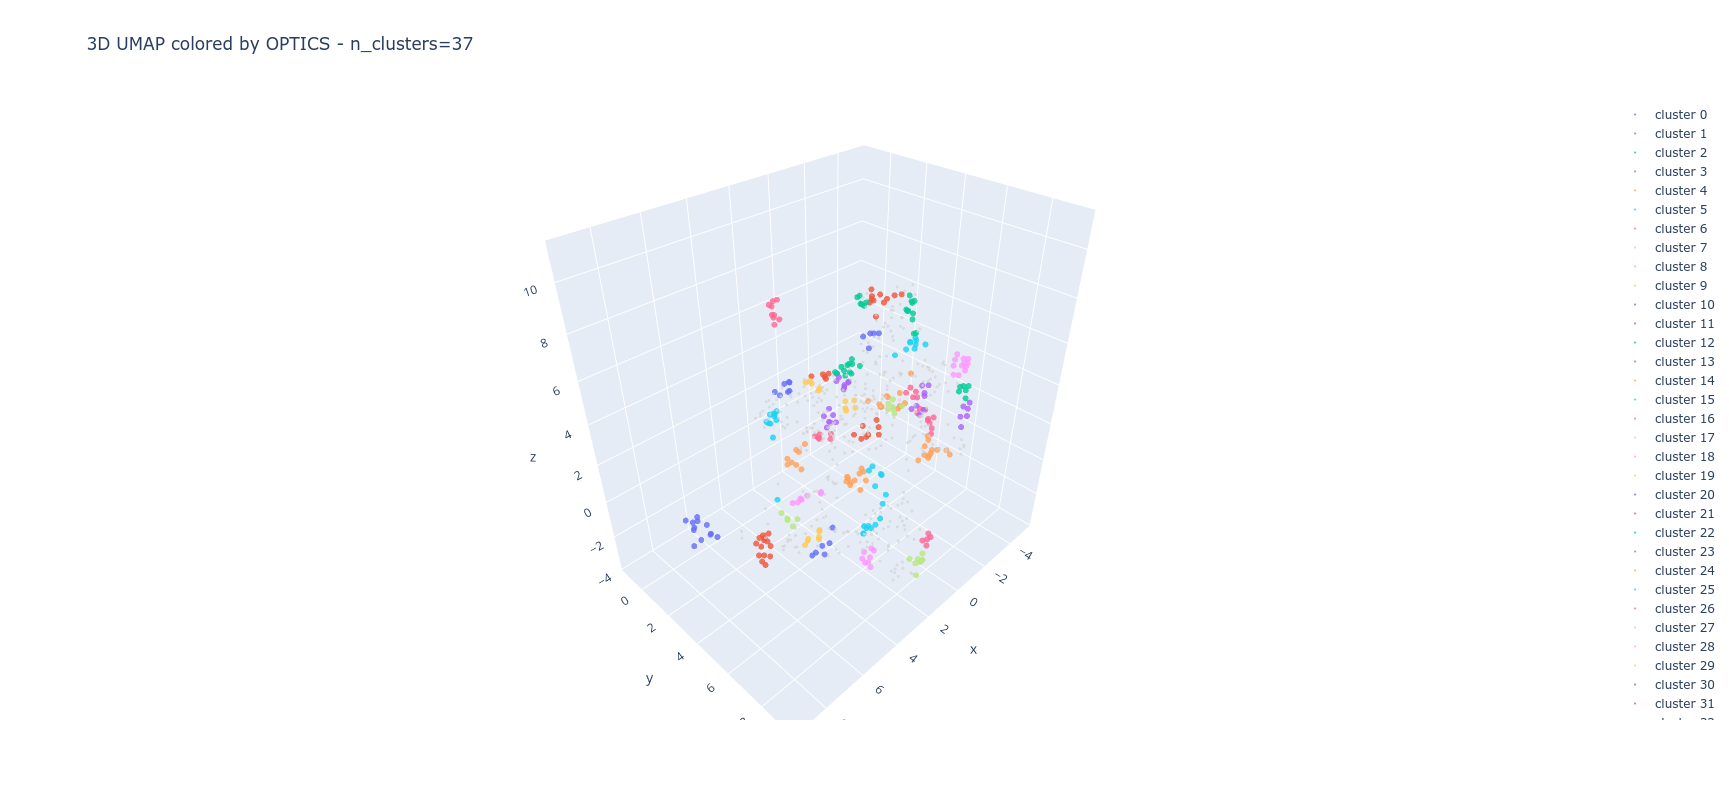

In [35]:
from sklearn.cluster import OPTICS

optics_labels = OPTICS().fit_predict(embedding_matrix)
n_clusters_optics = len(np.unique(optics_labels)) - 1
plot_embedding_3d(
    umap_3,
    optics_labels,
    f"3D UMAP colored by OPTICS - n_clusters={n_clusters_optics}",
)

It's interesting to see that moves did not cluster by type, but, by inspecting some of the clusters, they actually seem clustered by tactical meaning.
Not all clusters are equally good: some are a bit vague or contain moves which cannot be discriminated further without reading the effect (which my AE is not doing).

I noted that KMeans tends to like creating a LOT of clusters, by allowing a higher number of maximum clusters I found that setting k=100 or more gives a higher silohuette score, but then clusters don't give much information about the moves themselves and tend to be too specialized.
A more correct number of clusters seems to be identified by OPTICS, which however is unable to classify a good number of moves identifying them as noise.

A note again on the dimension of the latent space: a dimension lower than 8 seem not to give good clusters, probably too much information got lost, while a dimension higher did not improve the tactical meaning of clusters any further.
This aspect could be studied further.

Overall I'm satisfied with this result and I'm ready to move on to the next phase.

In [36]:
embedding_cols = [f"z_{idx:02d}" for idx in range(embedding_matrix.shape[1])]

move_embeddings_df = pd.concat(
    [
        moves_df[metadata_cols].reset_index(drop=True),
        pd.DataFrame(embedding_matrix, columns=embedding_cols),
    ],
    axis=1,
)

move_embeddings_df

,move_id,move_identifier,z_00,z_01,z_02,z_03,z_04,z_05,z_06,z_07
0,1,pound,-0.257199,2.729008,0.509297,0.061782,0.774410,-2.159383,-1.279751,-0.127553
1,5,megapunch,0.332601,2.113848,1.214002,0.493189,0.056766,-1.895556,-2.158710,0.012140
2,6,payday,-0.335888,1.806002,1.059692,0.324412,1.476195,-2.357455,-0.280518,-1.392214
3,7,firepunch,1.275672,-2.003148,1.256105,-0.520373,0.080711,0.093000,-1.750082,1.472394
4,8,icepunch,-0.101845,-2.206854,0.726414,-0.024911,1.023930,1.146302,-1.888173,1.297031
...,...,...,...,...,...,...,...,...,...,...
666,915,temperflare,1.539659,-2.457990,0.937881,-0.697826,1.221822,-0.894832,-0.396342,0.745129
667,916,supercellslam,1.141983,-2.036926,0.979915,-0.624565,2.263361,-0.854877,-0.849304,0.038934
668,917,psychicnoise,0.889376,-1.193622,0.320485,-0.630713,2.532642,-0.907510,0.902529,-1.739571
669,918,upperhand,1.124800,-0.280574,1.615726,-1.568086,1.533183,-1.962147,-0.699644,0.291188


# Evolution

Initially I thought about using the [DEAP](https://github.com/deap/DEAP) library, but I ended up writing most of the code myself anyways so I dropped the library and wrote everything from scratch.

## Battle MLP

This is the model which will take a decision on which move to play.

### Inputs and Preprocessing

| **What** |  **Size** | **Notes** |
| -------- | -------- | --------- |
| Moveset (own)| $4 \times 8$ dense vector | Vectors from the latent space of the AE |
| Current PP (own) | $4$ integers | |
| Move effectiveness score (own) | $4$ dense vector | The $\log_2$ of the multiplier due to the types of the pokemons and the moves |
| Base Statistics (own) | $8$ dense vector | Normalized value of each stat |
| Boosts (own) | $8$ dense vector | $\log_2$ of the multiplier each boost level gives |
| Current HP (both) | $2$ integers | |
| Weather and Terrain | $4 \times 2$ one-hot | |
| Major status (both) | $7 \times 2$ one-hot | |
| Volatile status (both) | $4 \times 2$ dense vectors | Precomputed approximation of what each status does |
| Side conditions (both) | $3 \times 2$ dense vectors | Precomputed approximation of what each side condition does |
| Turn number | $1$ integer | |

This gives exactly `90` input dimensions.

In [37]:
@lru_cache()
def _map_type_to_score(
    own_type_0: str,
    own_type_1: str | None,
    opp_type_0: str,
    opp_type_1: str | None,
    move_type: str,
) -> float:
    IMMUNITY_SCORE = -4.0

    type_chart: dict[str, dict[str, float]] = {
        "normal": {
            "rock": 0.5,
            "ghost": 0.0,
            "steel": 0.5,
        },
        "fire": {
            "fire": 0.5,
            "water": 0.5,
            "grass": 2.0,
            "ice": 2.0,
            "bug": 2.0,
            "rock": 0.5,
            "dragon": 0.5,
            "steel": 2.0,
        },
        "water": {
            "fire": 2.0,
            "water": 0.5,
            "grass": 0.5,
            "ground": 2.0,
            "rock": 2.0,
            "dragon": 0.5,
        },
        "electric": {
            "water": 2.0,
            "electric": 0.5,
            "grass": 0.5,
            "ground": 0.0,
            "flying": 2.0,
            "dragon": 0.5,
        },
        "grass": {
            "fire": 0.5,
            "water": 2.0,
            "grass": 0.5,
            "poison": 0.5,
            "ground": 2.0,
            "flying": 0.5,
            "bug": 0.5,
            "rock": 2.0,
            "dragon": 0.5,
            "steel": 0.5,
        },
        "ice": {
            "fire": 0.5,
            "water": 0.5,
            "grass": 2.0,
            "ice": 0.5,
            "ground": 2.0,
            "flying": 2.0,
            "dragon": 2.0,
            "steel": 0.5,
        },
        "fighting": {
            "normal": 2.0,
            "ice": 2.0,
            "poison": 0.5,
            "flying": 0.5,
            "psychic": 0.5,
            "bug": 0.5,
            "rock": 2.0,
            "ghost": 0.0,
            "dark": 2.0,
            "steel": 2.0,
            "fairy": 0.5,
        },
        "poison": {
            "grass": 2.0,
            "poison": 0.5,
            "ground": 0.5,
            "rock": 0.5,
            "ghost": 0.5,
            "steel": 0.0,
            "fairy": 2.0,
        },
        "ground": {
            "fire": 2.0,
            "electric": 2.0,
            "grass": 0.5,
            "poison": 2.0,
            "flying": 0.0,
            "bug": 0.5,
            "rock": 2.0,
            "steel": 2.0,
        },
        "flying": {
            "electric": 0.5,
            "grass": 2.0,
            "fighting": 2.0,
            "bug": 2.0,
            "rock": 0.5,
            "steel": 0.5,
        },
        "psychic": {
            "fighting": 2.0,
            "poison": 2.0,
            "psychic": 0.5,
            "dark": 0.0,
            "steel": 0.5,
        },
        "bug": {
            "fire": 0.5,
            "grass": 2.0,
            "fighting": 0.5,
            "poison": 0.5,
            "flying": 0.5,
            "psychic": 2.0,
            "ghost": 0.5,
            "dark": 2.0,
            "steel": 0.5,
            "fairy": 0.5,
        },
        "rock": {
            "fire": 2.0,
            "ice": 2.0,
            "fighting": 0.5,
            "ground": 0.5,
            "flying": 2.0,
            "bug": 2.0,
            "steel": 0.5,
        },
        "ghost": {
            "normal": 0.0,
            "psychic": 2.0,
            "ghost": 2.0,
            "dark": 0.5,
        },
        "dragon": {
            "dragon": 2.0,
            "steel": 0.5,
            "fairy": 0.0,
        },
        "dark": {
            "fighting": 0.5,
            "psychic": 2.0,
            "ghost": 2.0,
            "dark": 0.5,
            "fairy": 0.5,
        },
        "steel": {
            "fire": 0.5,
            "water": 0.5,
            "electric": 0.5,
            "ice": 2.0,
            "rock": 2.0,
            "steel": 0.5,
            "fairy": 2.0,
        },
        "fairy": {
            "fire": 0.5,
            "fighting": 2.0,
            "poison": 0.5,
            "dragon": 2.0,
            "dark": 2.0,
            "steel": 0.5,
        },
    }

    own_types = {t for t in [own_type_0, own_type_1] if t is not None}
    opp_types = {t for t in [opp_type_0, opp_type_1] if t is not None}

    stab = 1.5 if move_type in own_types else 1.0

    effectiveness = 1.0
    for defending_type in opp_types:
        effectiveness *= type_chart.get(move_type, {}).get(defending_type, 1.0)

    multiplier = stab * effectiveness

    if multiplier == 0.0:
        return IMMUNITY_SCORE

    return np.log2(multiplier)


def map_type_to_score(
    own_type: list[str],
    opp_type: list[str],
    move_type: str,
):
    assert len(own_type) > 0
    assert len(opp_type) > 0

    return _map_type_to_score(
        own_type[0],
        own_type[1] if len(own_type) > 1 else None,
        opp_type[0],
        opp_type[1] if len(opp_type) > 1 else None,
        move_type,
    )

In [38]:
def _combine_independent_probabilities(probabilities: np.ndarray) -> float:
    if probabilities.size == 0:
        return 0.0

    probabilities = np.clip(probabilities, 0.0, 1.0)
    return float(1.0 - np.prod(1.0 - probabilities))


ACTION_DENIAL_EFFECTS: dict[str, float] = {
    # Guaranteed loss of action.
    "flinch": 1.0,
    "mustrecharge": 1.0,
    "recharge": 1.0,
    # Probabilistic loss of action.
    "confusion": 1.0 / 3.0,
    "attract": 0.5,
    "infatuation": 0.5,
}

MOVE_RESTRICTION_EFFECTS: dict[str, float] = {
    # Approximate values because this function does not know the moveset.
    "taunt": 0.5,
    "encore": 0.75,
    "disable": 0.25,
    "torment": 0.25,
    "healblock": 0.25,
    "throatchop": 0.25,
    "imprison": 0.25,
    # Forced/locked move style effects.
    "choicelock": 0.75,
    "lockedmove": 0.75,
    "rollout": 0.75,
    "bide": 0.75,
    "twoturnmove": 0.75,
}

HP_DRIFT_EFFECTS: dict[str, float] = {
    # Harmful residual effects.
    "leechseed": -1.0 / 8.0,
    "partiallytrapped": -1.0 / 8.0,
    "partiallytrappedlock": -1.0 / 8.0,
    "wrap": -1.0 / 8.0,
    "bind": -1.0 / 8.0,
    "firespin": -1.0 / 8.0,
    "whirlpool": -1.0 / 8.0,
    "sandtomb": -1.0 / 8.0,
    "magmastorm": -1.0 / 8.0,
    "infestation": -1.0 / 8.0,
    "snaptrap": -1.0 / 8.0,
    "curse": -1.0 / 4.0,
    "nightmare": -1.0 / 4.0,
    # Beneficial residual effects.
    "aquaring": 1.0 / 16.0,
    "ingrain": 1.0 / 16.0,
}

PROTECTION_EFFECTS: dict[str, float] = {
    # Full protection.
    "protect": 1.0,
    "detect": 1.0,
    "kingsshield": 1.0,
    "spikyshield": 1.0,
    "banefulbunker": 1.0,
    "silktrap": 1.0,
    "burningbulwark": 1.0,
    "obstruct": 1.0,
    "maxguard": 1.0,
    # Approximate because substitute HP is unknown.
    "substitute": 0.5,
    # Semi-invulnerable two-turn move states.
    "fly": 1.0,
    "dig": 1.0,
    "dive": 1.0,
    "bounce": 1.0,
    "phantomforce": 1.0,
    "shadowforce": 1.0,
    # Charging moves are not true protection, but still encode some defensive tempo.
    "skyattack": 0.5,
    "solarbeam": 0.25,
    "solarblade": 0.25,
    # Survives lethal damage, but does not block damage.
    "endure": 0.5,
}


# Output order: [action_denial, move_restriction, hp_drift, protection]
def compute_volatile_status_summary(statuses: list[str]) -> np.ndarray:
    action_denial_probs = np.array(
        [
            ACTION_DENIAL_EFFECTS[s]
            for s in statuses
            if s in ACTION_DENIAL_EFFECTS
        ],
        dtype=np.float32,
    )

    move_restriction_values = np.array(
        [
            MOVE_RESTRICTION_EFFECTS[s]
            for s in statuses
            if s in MOVE_RESTRICTION_EFFECTS
        ],
        dtype=np.float32,
    )

    hp_drift_raw = sum(HP_DRIFT_EFFECTS.get(s, 0.0) for s in statuses)

    protection_values = np.array(
        [PROTECTION_EFFECTS[s] for s in statuses if s in PROTECTION_EFFECTS],
        dtype=np.float32,
    )

    action_denial = _combine_independent_probabilities(action_denial_probs)
    move_restriction = _combine_independent_probabilities(
        move_restriction_values
    )

    hp_drift = np.clip(hp_drift_raw / 0.25, -1.0, 1.0)

    protection = (
        float(np.max(protection_values)) if protection_values.size > 0 else 0.0
    )

    return np.array(
        [
            np.clip(action_denial, 0.0, 1.0),
            np.clip(move_restriction, 0.0, 1.0),
            hp_drift,
            np.clip(protection, 0.0, 1.0),
        ],
        dtype=np.float32,
    )

In [39]:
DEFENSIVE_SCREEN_EFFECTS: dict[str, float] = {
    "reflect": 0.35,
    "lightscreen": 0.35,
    "auroraveil": 0.5,
}

SPEED_SUPPORT_EFFECTS: dict[str, float] = {
    "tailwind": 1.0,
    # Usually irrelevant in no-switch 1v1 unless it already affected
    # the active Pokemon before the state snapshot.
    "stickyweb": -0.5,
}

STATUS_PROTECTION_EFFECTS: dict[str, float] = {
    "safeguard": 0.75,
    "mist": 0.25,
    "luckychant": 0.25,
}


#  Output order: [defensive_screen, speed_support, status_protection]
def compute_side_condition_summary(conditions: list[str]) -> np.ndarray:
    defensive_screen = (
        max(DEFENSIVE_SCREEN_EFFECTS.get(c, 0.0) for c in conditions)
        if conditions
        else 0.0
    )

    speed_support = sum(SPEED_SUPPORT_EFFECTS.get(c, 0.0) for c in conditions)

    status_protection = (
        max(STATUS_PROTECTION_EFFECTS.get(c, 0.0) for c in conditions)
        if conditions
        else 0.0
    )

    return np.array(
        [
            np.clip(defensive_screen, 0.0, 1.0),
            np.clip(speed_support, -1.0, 1.0),
            np.clip(status_protection, 0.0, 1.0),
        ],
        dtype=np.float32,
    )

In [40]:
ALL_WEATHERS = ("raindance", "sunnyday", "sandstorm", "snowscape")
ALL_TERRAINS = (
    "electricterrain",
    "grassyterrain",
    "mistyterrain",
    "psychicterrain",
)
ALL_MAJOR_STATUSES = ("brn", "par", "slp", "frz", "psn", "tox")


def make_onehot_map(states: tuple[str, ...]) -> dict[str, np.ndarray]:
    eye = np.eye(len(states), dtype=np.float32)
    mapping = {state: eye[i] for i, state in enumerate(states)}
    mapping[""] = np.zeros(len(states), dtype=np.float32)
    return mapping


weathers_encoding_map = make_onehot_map(ALL_WEATHERS)
terrains_encoding_map = make_onehot_map(ALL_TERRAINS)
major_statuses_encoding_map = make_onehot_map(ALL_MAJOR_STATUSES)

In [41]:
def compute_boost_score(boost: int, *, accuracy_like: bool = False) -> float:
    stage = int(np.clip(boost, -6, 6))
    base = 3 if accuracy_like else 2

    if stage >= 0:
        mult = (base + stage) / base
    else:
        mult = base / (base - stage)

    return float(np.log2(mult))

In [42]:
move_embedding_by_id = {
    row.move_identifier: row[embedding_cols].to_numpy(dtype=np.float32)
    for _, row in move_embeddings_df.iterrows()
}

move_type_by_id = dict(zip(moves_df["move_identifier"], moves_df["type"]))

In [43]:
BOOST_KEYS = ("atk", "def", "spa", "spd", "spe", "accuracy", "evasion")

In [44]:
def compute_input_to_mlp(p0: sdw.PlayerState, p1: sdw.PlayerState):
    move_ids_0 = [slot["id"] for slot in p0.slots]
    return np.concatenate(
        [
            np.asarray(
                [move_embedding_by_id[move_id] for move_id in move_ids_0],
                dtype=np.float32,
            ).flatten(),
            [slot["pp"] / slot["maxpp"] for slot in p0.slots],
            [
                map_type_to_score(
                    p0.pokemon["types"],
                    p1.pokemon["types"],
                    move_type_by_id[move_id],
                )
                for move_id in move_ids_0
            ],
            [p0.pokemon["stats"][k] / STAT_MAX[k] for k in STAT_KEYS],
            [
                compute_boost_score(
                    p0.pokemon["boosts"].get(boost, 0),
                    accuracy_like=(boost in ["accuracy", "evasion"]),
                )
                for boost in BOOST_KEYS
            ],
            [
                p0.pokemon["hp"] / max(1, p0.pokemon["stats"]["hp"]),
                p1.pokemon["hp"] / max(1, p1.pokemon["stats"]["hp"]),
            ],
            weathers_encoding_map[p0.weather],
            terrains_encoding_map[p0.terrain],
            major_statuses_encoding_map[p0.pokemon["status"]],
            major_statuses_encoding_map[p1.pokemon["status"]],
            compute_volatile_status_summary(p0.pokemon["volatiles"]),
            compute_volatile_status_summary(p1.pokemon["volatiles"]),
            compute_side_condition_summary(list(p0.side_conditions.keys())),
            compute_side_condition_summary(list(p1.side_conditions.keys())),
            [p0.turn / 100],
        ],
        dtype=np.float32,
    )

### Layout and Forward Pass

The MLP will be tiny, I picked a `90 -> 16 -> 8 -> 4` layout, where the outputs will be the logits of picking each move.
I chose `tanh` as activation function as it bounds post-activation values to $(-1, 1)$ making the MLP less sensitive to high weights.

In [45]:
MLPParamsSlices = list[tuple[tuple[int, int], tuple[int, int]]]

In [46]:
def compute_slices(layers: list[int]) -> MLPParamsSlices:
    cursor = 0
    params_slices = []

    for fan_in, fan_out in zip(layers[:-1], layers[1:]):
        w_start = cursor
        cursor += fan_in * fan_out
        w_end = cursor

        b_start = cursor
        cursor += fan_out
        b_end = cursor

        params_slices.append(((w_start, w_end), (b_start, b_end)))

    return params_slices


def count_params(slices: MLPParamsSlices) -> int:
    return slices[-1][1][1]

In [47]:
MLP_LAYOUT = [90, 16, 8, 4]
MLP_SLICES = compute_slices(MLP_LAYOUT)

count_params(MLP_SLICES)

1628

In [48]:
MLP_SLICES

[((0, 1440), (1440, 1456)),
 ((1456, 1584), (1584, 1592)),
 ((1592, 1624), (1624, 1628))]

In [49]:
def get_params_view(params: np.ndarray, layer: int):
    slice = MLP_SLICES[layer]
    w = params[slice[0][0] : slice[0][1]].reshape(
        MLP_LAYOUT[layer], MLP_LAYOUT[layer + 1]
    )
    b = params[slice[1][0] : slice[1][1]]

    assert np.shares_memory(w, params)
    assert np.shares_memory(b, params)

    return w, b

In [50]:
def mlp_forward(input: np.ndarray, params: np.ndarray) -> int:
    current = input

    for i in range(len(MLP_LAYOUT) - 2):
        w, b = get_params_view(params, i)
        current = np.tanh(current @ w + b)

    w, b = get_params_view(params, len(MLP_LAYOUT) - 2)
    logits = current @ w + b

    return int(np.argmax(logits))

## Defining the Agents

We define the genome of each agent as follows:
- `params` for the MLP, this is a flat vector which will then be sliced by looking at `MLP_SLICES`.
- `stats` as importance scores, i.e. logits of the fraction of available stat budget.
- `moves` is the array of the move ids.
- `types` is a tuple of integer indicating the type(s).
- `log_sigmas` is an array with one value per MLP layer which will control the variance of the mutation of the parameters of that layer. There will be one for weights and one for biases (so in this case $3 \times 2 = 6$).

Note that the representation for the genotype is different than what will be fed to the MLP (the fenotype).

In [51]:
STAT_MIN = 30
STAT_MAX = {
    "hp": 250,
    "atk": 190,
    "def": 250,
    "spa": 190,
    "spd": 250,
    "spe": 200,
}
STATS_TOTAL_MAX = 600

STAT_MAX_LIST = list(STAT_MAX.values())
STAT_KEYS = list(STAT_MAX.keys())

In [52]:
class OpponentAIType(Enum):
    RANDOM = 1
    HEURISTIC = 2
    RANDOM_MLP = 100
    CHAMPION_MLP = 101

In [53]:
@dataclass
class Agent:
    params: np.ndarray
    stats: np.ndarray
    moves: np.ndarray
    types: tuple[int, int]
    log_sigmas: np.ndarray

    fitness: float | None = None

    def invalidate_fitness(self) -> None:
        self.fitness = None

    @property
    def is_evaluated(self) -> bool:
        return self.fitness is not None

    def get_decision_function(
        self,
        opponent_policy: Callable[[sdw.PlayerState, sdw.PlayerState], int],
        rng,
    ) -> sdw.MoveSelector:
        def decider(
            p0: sdw.PlayerState, p1: sdw.PlayerState
        ) -> tuple[int, int]:
            input = compute_input_to_mlp(p0, p1)
            ai_move = mlp_forward(input, self.params)
            opponent_move = opponent_policy(p0, p1, rng)

            return int(ai_move), int(opponent_move)

        return decider

    def copy(self, copy_fitness=True, deep=True) -> "Agent":
        if deep:
            copy = Agent(
                self.params.copy(),
                self.stats.copy(),
                self.moves.copy(),
                self.types,
                self.log_sigmas.copy(),
            )
        else:
            copy = Agent(
                self.params,
                self.stats,
                self.moves,
                self.types,
                self.log_sigmas,
            )

        if copy_fitness:
            copy.fitness = self.fitness

        return copy

    def __repr__(self) -> str:
        return (
            "Agent(\n"
            f"  fitness={self.fitness},\n"
            f"  params={np.array2string(self.params, precision=3, suppress_small=True)},\n"
            f"  stats={np.array2string(self.stats, precision=3, suppress_small=True)},\n"
            f"  moves={np.array2string(self.moves, precision=3, suppress_small=True)},\n"
            f"  types={self.types},\n"
            f"  log_sigmas={np.array2string(self.log_sigmas, precision=3, suppress_small=True)}\n"
            ")"
        )

    def save(self, path: str | Path) -> None:
        path = Path(path)

        metadata = {
            "types": list(self.types),
            "fitness": float(self.fitness),
        }

        np.savez_compressed(
            path,
            params=self.params,
            stats=self.stats,
            moves=self.moves,
            log_sigmas=self.log_sigmas,
            metadata=np.array(json.dumps(metadata), dtype=np.str_),
        )

    @classmethod
    def load(cls, path: str | Path) -> "Agent":
        path = Path(path)

        with np.load(path, allow_pickle=False) as data:
            metadata = json.loads(str(data["metadata"]))

            agent = cls(
                params=data["params"].copy(),
                stats=data["stats"].copy(),
                moves=data["moves"].copy(),
                types=tuple(int(x) for x in metadata["types"]),
                log_sigmas=data["log_sigmas"].copy(),
                fitness=metadata["fitness"],
            )

        return agent

### Initialization

- Stats can just be initialized with random numbers, since the function below will handle all cases and always output a legal distribution.
- Types can be chosen randomly within the existing ones.
- MLP weights are choses using Xavier Uniform initialization, since this is the recommended one when using `tanh` as activation function.
- The first move is sampled at random, then the next ones are chosen in order to maximize the distance in the latent space, so that the moveset will be heterogeneous.

In [54]:
def validate_stats(stats: sdw.Stats) -> bool:
    all_below_max = all(value <= STAT_MAX[key] for key, value in stats.items())
    sum_below_max = sum(stats.values()) == STATS_TOTAL_MAX
    all_above_min = all(value >= STAT_MIN for value in stats.values())

    print(all_below_max, sum_below_max, all_above_min)

    return all_below_max and sum_below_max and all_above_min


def genome_stats_to_integer(stats: np.ndarray) -> dict[str, int]:
    stats01 = softmax(np.asarray(stats, dtype=float))

    if len(stats01) != len(STAT_KEYS):
        raise ValueError("stats01 and keys must have the same length")

    stats01 = np.clip(stats01, 0.0, 1.0)

    mins = np.array([STAT_MIN for _ in STAT_KEYS], dtype=int)
    maxs = np.array([STAT_MAX[key] for key in STAT_KEYS], dtype=int)
    caps = maxs - mins

    min_total = int(mins.sum())
    max_total = int(maxs.sum())

    if STATS_TOTAL_MAX < min_total:
        raise ValueError("STATS_TOTAL_MAX is below the sum of minimum stats")

    if STATS_TOTAL_MAX > max_total:
        raise ValueError("STATS_TOTAL_MAX is above the sum of maximum stats")

    extra_budget = STATS_TOTAL_MAX - min_total

    if extra_budget == 0:
        return {key: int(value) for key, value in zip(STAT_KEYS, mins)}

    # Preference for extra points.
    # Multiplying by caps means that 1.0 represents "I want this stat near its own max".
    weights = stats01 * caps

    # If all normalized values are 0, there is no preference signal.
    # Fall back to distributing by available capacity.
    if weights.sum() == 0:
        weights = caps.astype(float)

    extras = np.zeros(len(STAT_KEYS), dtype=int)
    remaining = extra_budget

    active = caps > 0

    while remaining > 0:
        active_indices = np.where(active)[0]

        if len(active_indices) == 0:
            raise RuntimeError(
                "No remaining capacity but budget is not exhausted"
            )

        active_weights = weights[active_indices]

        if active_weights.sum() == 0:
            active_weights = caps[active_indices].astype(float)

        quotas = remaining * active_weights / active_weights.sum()

        whole = np.floor(quotas).astype(int)

        # Do not exceed remaining capacity for each stat.
        available = caps[active_indices] - extras[active_indices]
        whole = np.minimum(whole, available)

        extras[active_indices] += whole
        remaining -= int(whole.sum())

        if remaining == 0:
            break

        # Largest remainder allocation, stable by original key order.
        remainders = quotas - np.floor(quotas)

        order = sorted(
            active_indices,
            key=lambda i: (-remainders[list(active_indices).index(i)], i),
        )

        allocated_any = False

        for i in order:
            if remaining == 0:
                break

            if extras[i] < caps[i]:
                extras[i] += 1
                remaining -= 1
                allocated_any = True

        if not allocated_any:
            raise RuntimeError("Could not allocate remaining stat points")

        active = extras < caps

    values = mins + extras

    return {key: int(value) for key, value in zip(STAT_KEYS, values)}


def random_valid_stats(rng) -> np.ndarray:
    return rng.random(len(STAT_KEYS))

In [55]:
def xavier_uniform(fan_in, fan_out, rng):
    limit = np.sqrt(6 / (fan_in + fan_out))
    return rng.uniform(-limit, limit, (fan_in, fan_out))

In [56]:
_feature_cols = [
    c for c in move_embeddings_df.columns if c not in metadata_cols
]

_X = move_embeddings_df[_feature_cols].to_numpy()


def pick_random_moveset(rng):
    k = 4

    first = rng.integers(len(move_embeddings_df))

    selected = [first]

    min_dist = pairwise_distances(_X, _X[[first]]).ravel()

    for _ in range(1, k):
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)

        new_dist = pairwise_distances(_X, _X[[next_idx]]).ravel()
        min_dist = np.minimum(min_dist, new_dist)

    return np.array(selected)
    # , move_embeddings_df.iloc[selected]["move_identifier"].tolist()

In [57]:
def init_agent_at_random(rng) -> Agent:
    params_parts = []
    for i, input_size in enumerate(MLP_LAYOUT[:-1]):
        output_size = MLP_LAYOUT[i + 1]

        W = xavier_uniform(input_size, output_size, rng).flatten()
        b = np.zeros(output_size)

        params_parts.extend([W, b])

    params = np.concatenate(params_parts)

    stats = random_valid_stats(rng)

    types = (
        rng.integers(len(types_unique), dtype=int),
        rng.integers(len(types_unique), dtype=int),
    )

    moves = pick_random_moveset(rng)

    log_sigmas = np.log(
        np.ones((len(MLP_LAYOUT) - 1) * 2) * 0.05
    )  # initially set sigma = 0.05 for all layers

    return Agent(params, stats, moves, types, log_sigmas)

## Generating offspring

New agents are created both by mutation and crossover.

In [58]:
def repair_duplicate_moves(moves: np.ndarray, rng) -> np.ndarray:
    moves = moves.copy()
    used = set()

    for i, move in enumerate(moves):
        move = int(move)

        if move not in used:
            used.add(move)
            continue

        # Resample until unique. Fine because moveset size is only 4.
        while True:
            new_move = int(rng.integers(len(move_embeddings_df)))
            if new_move not in used:
                moves[i] = new_move
                used.add(new_move)
                break

    return moves

### Mutations

Mutation is the main mechanism driving diversity in the MLP weights as crossing over parts of them to other agents will distrupt the whole network.
Variances for the mutation of the weights also mutate along with everything else using a simple gaussian noise.

Types are categorical variables, therefore they mutate just using a jump.
There is also a small probability that the type collapses to a monotype.

Moves mutate by either moving to another one close to the original one in the latent space, or by performing a random jump.
When performing a local jump, the probability of choosing a certain move is a gaussian distribution over the distances.

Stats also change using gaussian noise with a fixed sigma.

In [59]:
def mutate_sigma(agent: Agent, rng, tau=0.10):
    LOG_SIGMA_MIN = np.log(1e-4)
    LOG_SIGMA_MAX = np.log(0.5)

    agent.log_sigmas = np.clip(
        agent.log_sigmas + rng.normal(0, tau, size=agent.log_sigmas.shape),
        LOG_SIGMA_MIN,
        LOG_SIGMA_MAX,
    )

    return agent

In [60]:
def mutate_params(agent: Agent, rng, indpb=0.05):
    params = agent.params.copy()
    sigmas = np.exp(agent.log_sigmas)

    for layer in range(len(MLP_LAYOUT) - 1):
        w, b = get_params_view(params, layer)
        sigma_w = sigmas[layer * 2]
        sigma_b = sigmas[layer * 2 + 1]

        mask_w = rng.random(w.shape) < indpb
        mask_b = rng.random(b.shape) < indpb

        w[mask_w] += rng.normal(0, sigma_w, size=mask_w.sum())
        b[mask_b] += rng.normal(0, sigma_b, size=mask_b.sum())

        assert np.shares_memory(w, params)
        assert np.shares_memory(b, params)

    agent.params = np.clip(params, -5, 5)
    return agent

In [61]:
def mutate_type(agent: Agent, rng, p=0.25, p_collapse=0.05):
    t1, t2 = agent.types

    if rng.random() < p:
        t1 = rng.integers(len(types_unique), dtype=int)

    if rng.random() < p:
        t2 = rng.integers(len(types_unique), dtype=int)

    if rng.random() < p_collapse:
        if rng.random() < 0.5:
            t2 = t1
        else:
            t1 = t2

    agent.types = (t1, t2)
    return agent

In [62]:
SIGMA_MOVE_CHANGE = 0.5

_feature_cols = [
    c for c in move_embeddings_df.columns if c not in metadata_cols
]

_X = move_embeddings_df[_feature_cols].to_numpy()

move_dist_matrix = cdist(_X, _X, metric="euclidean")
_logits = -(move_dist_matrix**2) / (2.0 * SIGMA_MOVE_CHANGE**2)
np.fill_diagonal(_logits, -np.inf)

move_local_change_p = softmax(_logits, axis=1)

#  pd.Series(move_local_change_p[5][move_local_change_p[5] > 0.01])

In [63]:
def mutate_moveset(agent: Agent, rng, p_replace=0.25, p_jump=0.2):
    moves = agent.moves.copy()

    for i in range(len(moves)):
        if rng.random() < p_replace:
            current = moves[i]

            if rng.random() > p_jump:
                probs = move_local_change_p[current]
                moves[i] = rng.choice(len(move_embeddings_df), p=probs)
            else:
                moves[i] = rng.integers(len(move_embeddings_df))

    agent.moves = repair_duplicate_moves(moves, rng)
    return agent

In [64]:
def mutate_stats(agent: Agent, rng, sigma=0.1, indpb=0.5):
    stats = agent.stats.copy()

    mask = rng.random(stats.shape) < indpb
    stats[mask] += rng.normal(0, sigma, size=mask.sum())

    agent.stats = stats
    return agent

In [65]:
def mutate_all(agent: Agent, rng):
    if rng.random() < 0.40:
        agent = mutate_moveset(agent, rng)

    if rng.random() < 0.10:
        agent = mutate_type(agent, rng)

    if rng.random() < 0.70:
        agent = mutate_stats(agent, rng)

    if rng.random() < 0.8:
        agent = mutate_sigma(agent, rng)

    if rng.random() < 0.95:
        agent = mutate_params(agent, rng)

    return agent

### Crossover

Crossover is implemented for types, stats, and the moveset.
The MLP also can be crossed over but the whole network gets exchanged between the parents (so really no crossover occurs, just a swap),
but I think this can help to avoid making the weights specialize too much on a certain moveset or type.

In [66]:
def mate(a: Agent, b: Agent, rng):
    # Moveset crossover
    if rng.random() < 0.5:
        a.moves = a.moves.copy()
        b.moves = b.moves.copy()

        i = rng.integers(len(a.moves))
        j = rng.integers(len(b.moves))

        a.moves[i], b.moves[j] = b.moves[j], a.moves[i]

        a.moves = repair_duplicate_moves(a.moves, rng)
        b.moves = repair_duplicate_moves(b.moves, rng)

    # Type crossover
    if rng.random() < 0.5:
        i = 0 if rng.random() < 0.5 else 1
        j = 0 if rng.random() < 0.5 else 1

        t_a = (a.types[-(i - 1)], b.types[j])
        t_b = (b.types[-(j - 1)], a.types[i])

        a.types = t_a
        b.types = t_b

    # Stat crossover
    if rng.random() < 0.5:
        alpha = rng.random()
        xa = a.stats.copy()
        xb = b.stats.copy()
        a.stats = alpha * xa + (1 - alpha) * xb
        b.stats = alpha * xb + (1 - alpha) * xa

    # MLP crossover
    if rng.random() < 0.2:
        a.params, b.params = b.params.copy(), a.params.copy()

    return a, b

### Make Offspring

Once we have all the mutation and crossover in place we can write a function which, given the current population generates new offspring.

In [67]:
def make_offspring(
    n_offspring: int,
    population: list[Agent],
    rng,
    crossover_p: float,
) -> list[Agent]:
    offspring = []

    while len(offspring) < n_offspring:
        parent_ids = rng.choice(len(population), size=2, replace=False)
        p1 = population[parent_ids[0]].copy(deep=False)
        p2 = population[parent_ids[1]].copy(deep=False)

        if rng.random() < crossover_p:
            children = mate(p1, p2, rng)
            if rng.random() < 0.5:
                mutate_all(children[0], rng)
            if rng.random() < 0.5:
                mutate_all(children[1], rng)

            offspring.extend(children)

            continue

        offspring.append(mutate_all(p1, rng))
        offspring.append(mutate_all(p2, rng))

    return offspring

## Choosing Opponents

This part revealed to be the hardest and most incomplete part of this project.

To evaluate my agent I need to make it battle some opponents, however I found it hard to find an efficient way to make opponents "smart".
Each opponent has a legal (as in "it exists and it is valid in the actual game") physical configuration, i.e. species, stats and moveset, and its own battle policy.

The physical configuration is either chosen at random or from a pool of ChatGPT-crafted "decent" opponent, which should contain enough variety and different play strategies.

However finding a good battle policy for opponents deemed to be very hard.
Each opponet will pick one of the following policies: some opponets just play at random, some follow some simple heuristic, some use the same MLP params from some other individual in the population.

Coevolution is definitely an interesing in theory, but it may lead to the agents learning how to exploit their own flaws rather than actually fixing them.

In [68]:
OpponentConfig = tuple[sdw.OpponentConfig, Callable, float]

In [69]:
def sample_adversaries(
    n: int, rng, best_agent: Agent | None, population: list[Agent]
) -> list[OpponentConfig]:
    opponent_configs = []

    for _ in range(n):
        policy = rng.choice(
            np.array(list(opponent_policies.keys())),
            p=np.array([0.3, 0.3, 0.3, 0.1]),
        )

        if policy == OpponentAIType.CHAMPION_MLP and best_agent is None:
            policy = OpponentAIType.RANDOM_MLP

        opponent: sdw.OpponentConfig
        if rng.random() < 0.2:
            opponent = {"type": "random"}
        else:
            opponent = {
                "type": "specified",
                **selected_opponents_pool[
                    int(rng.integers(len(selected_opponents_pool)))
                ],
            }

        match policy:
            case OpponentAIType.RANDOM:
                policy_fn = random_opponent_policy
            case OpponentAIType.HEURISTIC:
                policy_fn = heuristic_opponent_policy
            case OpponentAIType.RANDOM_MLP:
                policy_fn = mlp_opponent_policy_factory(
                    population[int(rng.integers(len(population)))].params
                )
            case OpponentAIType.CHAMPION_MLP:
                policy_fn = mlp_opponent_policy_factory(best_agent.params)

        opponent_configs.append(
            (opponent, policy_fn, opponent_policies[policy])
        )

    return opponent_configs

### Opponent Battle Policies

In [70]:
def random_opponent_policy(p0: sdw.PlayerState, p1: sdw.PlayerState, rng):
    return rng.integers(4)

In [71]:
move_info_by_id = {
    row.move_identifier: (row.power, row.type)
    for row in moves_df.itertuples(index=False)
}

In [72]:
def heuristic_opponent_policy(p0: sdw.PlayerState, p1: sdw.PlayerState, rng):
    try:
        moves = [move_info_by_id[slot["id"]] for slot in p1.slots]
    except Exception as e:
        for slot in p1.slots:
            print(slot["id"])
        raise e

    power_estimate = [
        move[0]
        * (
            2.0
            ** (
                map_type_to_score(
                    p1.pokemon["types"],
                    p0.pokemon["types"],
                    move[1],
                )
            )
        )
        for move in moves
    ]

    return np.argmax(power_estimate)

In [73]:
def mlp_opponent_policy_factory(params: np.ndarray):
    def policy(p0: sdw.PlayerState, p1: sdw.PlayerState, rng):
        return mlp_forward(compute_input_to_mlp(p1, p0), params)

    return policy

In [74]:
opponent_policies = {
    OpponentAIType.RANDOM: 0.5,
    OpponentAIType.HEURISTIC: 1.0,
    OpponentAIType.RANDOM_MLP: 1.5,
    OpponentAIType.CHAMPION_MLP: 1.75,
}

In [75]:
selected_opponents_pool = [
    # Fast special attacker: simple pressure, coverage-based
    {
        "species": "alakazam",
        "moves": ["psychic", "focusblast", "shadowball", "energyball"],
    },
    # Fast physical attacker: contact offense + priority
    {
        "species": "weavile",
        "moves": ["icepunch", "knockoff", "iceshard", "lowsweep"],
    },
    # Bulky setup sweeper: tries to boost, then sweep
    {
        "species": "dragonite",
        "moves": ["dragondance", "dragonclaw", "firepunch", "roost"],
    },
    # Physical wallbreaker: very high immediate damage
    {
        "species": "machamp",
        "moves": ["closecombat", "knockoff", "stoneedge", "icepunch"],
    },
    # Special wallbreaker: powerful but slower
    {
        "species": "hydreigon",
        "moves": ["dracometeor", "darkpulse", "flamethrower", "flashcannon"],
    },
    # Bulky recovery/stall-ish: sustain + chip
    {"species": "milotic", "moves": ["scald", "recover", "icebeam", "toxic"]},
    # Defensive poison/status control
    {
        "species": "toxapex",
        "moves": ["scald", "recover", "toxic", "venoshock"],
    },
    # Burn-control physical wall
    {
        "species": "rotom",
        "moves": ["thunderbolt", "shadowball", "willowisp", "thunderwave"],
    },
    # Priority-focused attacker
    {
        "species": "scizor",
        "moves": ["bulletpunch", "xscissor", "swordsdance", "roost"],
    },
    # Setup special sweeper
    {
        "species": "volcarona",
        "moves": ["quiverdance", "fierydance", "bugbuzz", "gigadrain"],
    },
    # Setup physical sweeper with coverage
    {
        "species": "gyarados",
        "moves": ["dragondance", "waterfall", "crunch", "icefang"],
    },
    # Curse/rest bulky win condition
    {
        "species": "snorlax",
        "moves": ["curse", "bodyslam", "rest", "crunch"],
    },
    # Leech seed/protect attrition
    {
        "species": "ferrothorn",
        "moves": ["powerwhip", "gyroball", "bodypress", "protect"],
    },
    # Hazard/control style, even in 1v1 this tests bad moves / field awareness
    {
        "species": "skarmory",
        "moves": ["bravebird", "roost", "spikes", "whirlwind"],
    },
    # Trick/disruption style
    {
        "species": "gardevoir",
        "moves": ["moonblast", "psychic", "thunderbolt", "calmmind"],
    },
    # Mixed attacker
    {
        "species": "infernape",
        "moves": ["closecombat", "flareblitz", "grassknot", "machpunch"],
    },
    # Weather-dependent recovery / bulky grass
    {
        "species": "venusaur",
        "moves": ["gigadrain", "sludgebomb", "synthesis", "earthpower"],
    },
    # Electric pivot-like attacker
    {
        "species": "jolteon",
        "moves": ["thunderbolt", "voltswitch", "shadowball", "thunderwave"],
    },
    # Ground-type wallbreaker
    {
        "species": "mamoswine",
        "moves": ["earthquake", "iciclecrash", "iceshard", "stoneedge"],
    },
    # Bulky ground with recovery
    {
        "species": "hippowdon",
        "moves": ["earthquake", "slackoff", "stoneedge", "toxic"],
    },
    # Calm Mind bulky special setup
    {
        "species": "slowbro",
        "moves": ["scald", "psyshock", "calmmind", "slackoff"],
    },
    # Nasty Plot special sweeper
    {
        "species": "lucario",
        "moves": ["nastyplot", "aurasphere", "flashcannon", "vacuumwave"],
    },
    # Swords Dance physical sweeper
    {
        "species": "garchomp",
        "moves": ["swordsdance", "earthquake", "dragonclaw", "stoneedge"],
    },
    # Annoying status + recovery
    {
        "species": "umbreon",
        "moves": ["foulplay", "toxic", "moonlight", "protect"],
    },
    # High-risk inaccurate nukes
    {
        "species": "nidoking",
        "moves": ["earthpower", "sludgewave", "fireblast", "thunderbolt"],
    },
    # Anti-setup phazing-ish tank
    {
        "species": "suicune",
        "moves": ["scald", "icebeam", "calmmind", "rest"],
    },
    # Frail glass cannon
    {
        "species": "gengar",
        "moves": ["shadowball", "sludgewave", "focusblast", "destinybond"],
    },
    # Rock polish / speed-boosting physical attacker
    {
        "species": "rhyperior",
        "moves": ["rockpolish", "stoneedge", "earthquake", "megahorn"],
    },
    # Screens/support-ish opponent, tests whether your agent punishes low damage
    {
        "species": "klefki",
        "moves": ["flashcannon", "dazzlinggleam", "reflect", "lightscreen"],
    },
    # Pure brute-force legendary baseline
    {
        "species": "mewtwo",
        "moves": ["psychic", "aurasphere", "icebeam", "recover"],
    },
    # Physical priority / setup
    {
        "species": "azumarill",
        "moves": ["liquidation", "playrough", "icepunch", "waterfall"],
    },
    {
        "species": "bisharp",
        "moves": ["swordsdance", "ironhead", "nightslash", "knockoff"],
    },
    {
        "species": "breloom",
        "moves": ["swordsdance", "machpunch", "bulletseed", "rocktomb"],
    },
    {
        "species": "crawdaunt",
        "moves": ["swordsdance", "crabhammer", "knockoff", "crunch"],
    },
    {
        "species": "mimikyu",
        "moves": ["swordsdance", "playrough", "shadowclaw", "shadowsneak"],
    },
    {
        "species": "metagross",
        "moves": ["meteormash", "zenheadbutt", "earthquake", "bulletpunch"],
    },
    {
        "species": "conkeldurr",
        "moves": ["bulkup", "drainpunch", "icepunch", "knockoff"],
    },
    {
        "species": "staraptor",
        "moves": ["bravebird", "closecombat", "doubleedge", "quickattack"],
    },
    # Physical wallbreakers
    {
        "species": "darmanitan",
        "moves": ["flareblitz", "earthquake", "rockslide", "uturn"],
    },
    {
        "species": "heracross",
        "moves": ["closecombat", "megahorn", "stoneedge", "swordsdance"],
    },
    {
        "species": "krookodile",
        "moves": ["earthquake", "knockoff", "stoneedge", "taunt"],
    },
    {
        "species": "electivire",
        "moves": ["wildcharge", "icepunch", "earthquake", "crosschop"],
    },
    {
        "species": "rampardos",
        "moves": ["headsmash", "earthquake", "zenheadbutt", "firepunch"],
    },
    {
        "species": "slaking",
        "moves": ["gigaimpact", "earthquake", "hammerarm", "suckerpunch"],
    },
    {
        "species": "archeops",
        "moves": ["stoneedge", "acrobatics", "earthquake", "uturn"],
    },
    {
        "species": "haxorus",
        "moves": ["dragondance", "outrage", "earthquake", "poisonjab"],
    },
    # Fast offense
    {
        "species": "aerodactyl",
        "moves": ["stoneedge", "dualwingbeat", "earthquake", "taunt"],
    },
    {
        "species": "sceptile",
        "moves": ["leafstorm", "dragonpulse", "focusblast", "gigadrain"],
    },
    {
        "species": "greninja",
        "moves": ["hydropump", "darkpulse", "icebeam", "gunkshot"],
    },
    {
        "species": "dragapult",
        "moves": ["dragondarts", "phantomforce", "uturn", "flamethrower"],
    },
    {
        "species": "meowscarada",
        "moves": ["flowertrick", "knockoff", "playrough", "uturn"],
    },
    {
        "species": "zeraora",
        "moves": ["wildcharge", "closecombat", "knockoff", "bulkup"],
    },
    {
        "species": "starmie",
        "moves": ["hydropump", "psychic", "icebeam", "recover"],
    },
    # Special setup sweepers
    {
        "species": "chandelure",
        "moves": ["calmmind", "shadowball", "flamethrower", "energyball"],
    },
    {
        "species": "houndoom",
        "moves": ["nastyplot", "fireblast", "darkpulse", "willowisp"],
    },
    {
        "species": "porygonz",
        "moves": ["nastyplot", "triattack", "icebeam", "thunderbolt"],
    },
    {
        "species": "espeon",
        "moves": ["calmmind", "psychic", "dazzlinggleam", "shadowball"],
    },
    {
        "species": "ribombee",
        "moves": ["quiverdance", "dazzlinggleam", "bugbuzz", "psychic"],
    },
    {
        "species": "delphox",
        "moves": ["nastyplot", "flamethrower", "psychic", "grassknot"],
    },
    {
        "species": "raikou",
        "moves": ["calmmind", "thunderbolt", "extrasensory", "scald"],
    },
    # Bulky special setup / sustain
    {
        "species": "reuniclus",
        "moves": ["calmmind", "psychic", "focusblast", "recover"],
    },
    {
        "species": "clefable",
        "moves": ["calmmind", "moonblast", "flamethrower", "moonlight"],
    },
    {
        "species": "florges",
        "moves": ["calmmind", "moonblast", "wish", "protect"],
    },
    {
        "species": "primarina",
        "moves": ["calmmind", "sparklingaria", "moonblast", "psychic"],
    },
    {
        "species": "latias",
        "moves": ["calmmind", "dracometeor", "psychic", "recover"],
    },
    {
        "species": "necrozma",
        "moves": ["calmmind", "photongeyser", "heatwave", "moonlight"],
    },
    # Defensive / attrition
    {"species": "mandibuzz", "moves": ["foulplay", "roost", "toxic", "taunt"]},
    {
        "species": "quagsire",
        "moves": ["earthquake", "liquidation", "rest", "toxic"],
    },
    {
        "species": "clodsire",
        "moves": ["earthquake", "poisonjab", "rest", "toxic"],
    },
    {
        "species": "tangrowth",
        "moves": ["gigadrain", "knockoff", "earthquake", "synthesis"],
    },
    {"species": "vaporeon", "moves": ["scald", "icebeam", "rest", "protect"]},
    {
        "species": "sableye",
        "moves": ["foulplay", "knockoff", "recover", "willowisp"],
    },
    {
        "species": "palossand",
        "moves": ["earthpower", "shadowball", "shoreup", "gigadrain"],
    },
    {
        "species": "avalugg",
        "moves": ["avalanche", "bodypress", "recover", "irondefense"],
    },
    # Iron Defense / Body Press style
    {
        "species": "corviknight",
        "moves": ["irondefense", "bodypress", "bravebird", "uturn"],
    },
    {
        "species": "magnezone",
        "moves": ["irondefense", "bodypress", "thunderbolt", "flashcannon"],
    },
    {
        "species": "bronzong",
        "moves": ["irondefense", "bodypress", "gyroball", "rest"],
    },
    {
        "species": "steelix",
        "moves": ["curse", "earthquake", "ironhead", "bodypress"],
    },
    {
        "species": "forretress",
        "moves": ["irondefense", "bodypress", "gyroball", "explosion"],
    },
    # Shell Smash / explosive setup
    {
        "species": "blastoise",
        "moves": ["shellsmash", "surf", "icebeam", "darkpulse"],
    },
    {
        "species": "cloyster",
        "moves": ["shellsmash", "iciclespear", "rockblast", "liquidation"],
    },
    {
        "species": "omastar",
        "moves": ["shellsmash", "surf", "icebeam", "earthpower"],
    },
    {
        "species": "minior",
        "moves": ["shellsmash", "acrobatics", "stoneedge", "earthquake"],
    },
    {
        "species": "cetitan",
        "moves": ["icespinner", "liquidation", "iceshard", "earthquake"],
    },
    # Mixed attackers
    {
        "species": "goodra",
        "moves": ["dracometeor", "sludgebomb", "thunderbolt", "fireblast"],
    },
    {
        "species": "nidoking",
        "moves": ["earthpower", "sludgewave", "fireblast", "thunderbolt"],
    },
    {
        "species": "salamence",
        "moves": ["dragondance", "dragonclaw", "earthquake", "fireblast"],
    },
    {
        "species": "kommoo",
        "moves": [
            "clangingscales",
            "closecombat",
            "flamethrower",
            "dragondance",
        ],
    },
    {
        "species": "ironvaliant",
        "moves": ["moonblast", "closecombat", "thunderbolt", "swordsdance"],
    },
    {
        "species": "infernape",
        "moves": ["closecombat", "flareblitz", "grassknot", "machpunch"],
    },
    # Status/control without sleep/evasion
    {
        "species": "jolteon",
        "moves": ["thunderbolt", "voltswitch", "shadowball", "thunderwave"],
    },
    {
        "species": "togekiss",
        "moves": ["airslash", "aurasphere", "flamethrower", "thunderwave"],
    },
    {
        "species": "grimmsnarl",
        "moves": ["bulkup", "spiritbreak", "suckerpunch", "thunderwave"],
    },
    {
        "species": "tinkaton",
        "moves": ["gigatonhammer", "playrough", "knockoff", "thunderwave"],
    },
    {
        "species": "moltres",
        "moves": ["hurricane", "flamethrower", "roost", "willowisp"],
    },
    {
        "species": "arcanine",
        "moves": ["flareblitz", "extremespeed", "closecombat", "willowisp"],
    },
    # Perish / weird win conditions
    {
        "species": "lapras",
        "moves": ["icebeam", "hydropump", "thunderbolt", "perishsong"],
    },
    {
        "species": "politoed",
        "moves": ["surf", "icebeam", "encore", "perishsong"],
    },
    {
        "species": "falinks",
        "moves": ["noretreat", "closecombat", "megahorn", "ironhead"],
    },
    {
        "species": "golisopod",
        "moves": [
            "firstimpression",
            "liquidation",
            "leechlife",
            "swordsdance",
        ],
    },
    {
        "species": "maushold",
        "moves": ["populationbomb", "tidyup", "playrough", "bulletseed"],
    },
    # No-ability stress tests: normally ability-dependent mons
    {
        "species": "pelipper",
        "moves": ["hurricane", "surf", "roost", "knockoff"],
    },
    {
        "species": "abomasnow",
        "moves": ["woodhammer", "blizzard", "earthquake", "iceshard"],
    },
    {
        "species": "ninjask",
        "moves": ["swordsdance", "xscissor", "acrobatics", "protect"],
    },
    {
        "species": "sharpedo",
        "moves": ["crunch", "liquidation", "icefang", "protect"],
    },
    {
        "species": "sylveon",
        "moves": ["hypervoice", "moonblast", "calmmind", "shadowball"],
    },
    {
        "species": "sableye",
        "moves": ["willowisp", "recover", "foulplay", "taunt"],
    },
    # Paradox / modern strong baselines
    {
        "species": "greattusk",
        "moves": ["headlongrush", "closecombat", "knockoff", "rapidspin"],
    },
    {
        "species": "ironhands",
        "moves": ["swordsdance", "drainpunch", "thunderpunch", "icepunch"],
    },
    {
        "species": "ironmoth",
        "moves": ["agility", "fierydance", "sludgewave", "energyball"],
    },
    {
        "species": "sandyshocks",
        "moves": ["thunderbolt", "earthpower", "flashcannon", "stealthrock"],
    },
    {
        "species": "slitherwing",
        "moves": ["firstimpression", "closecombat", "leechlife", "flareblitz"],
    },
    {
        "species": "walkingwake",
        "moves": ["hydropump", "dracometeor", "flamethrower", "dragonpulse"],
    },
    # Strong legendary / high-BST baselines
    {
        "species": "zapdos",
        "moves": ["thunderbolt", "hurricane", "heatwave", "roost"],
    },
    {
        "species": "moltres",
        "moves": ["flamethrower", "hurricane", "roost", "willowisp"],
    },
    {
        "species": "terrakion",
        "moves": ["swordsdance", "closecombat", "stoneedge", "earthquake"],
    },
    {
        "species": "cobalion",
        "moves": ["swordsdance", "closecombat", "ironhead", "stoneedge"],
    },
    {
        "species": "latios",
        "moves": ["dracometeor", "psychic", "aurasphere", "calmmind"],
    },
    {
        "species": "heatran",
        "moves": ["magmastorm", "earthpower", "flashcannon", "taunt"],
    },
    # Lower-tier / oddball opponents for robustness
    {
        "species": "sigilyph",
        "moves": ["calmmind", "psychic", "airslash", "roost"],
    },
    {
        "species": "drifblim",
        "moves": ["calmmind", "shadowball", "airslash", "thunderbolt"],
    },
    {
        "species": "zebstrika",
        "moves": [
            "wildcharge",
            "flamecharge",
            "highhorsepower",
            "quickattack",
        ],
    },
    {
        "species": "beartic",
        "moves": ["iciclecrash", "liquidation", "superpower", "aquajet"],
    },
    {
        "species": "gigalith",
        "moves": ["stealthrock", "stoneedge", "earthquake", "bodypress"],
    },
    {
        "species": "tentacruel",
        "moves": ["surf", "sludgewave", "icebeam", "acidspray"],
    },
    {
        "species": "coalossal",
        "moves": ["flamethrower", "powergem", "earthpower", "rapidspin"],
    },
    {
        "species": "scovillain",
        "moves": ["flamethrower", "energyball", "growth", "crunch"],
    },
]

## Fitness

The fitness will be computed using this formula
$$
\begin{align*}
\text{fitness for 1 battle} = &\, \text{difficulty multiplier} \cdot \mathbb I(\text{battle won}) \\
& + 0.25 \cdot \text{own remaining HP fraction} \\
& - 0.25 \cdot \text{opponent remaining HP fraction} \\
& - 0.05  \cdot \text{number of turns}
\end{align*}
$$
where $\mathbb I$ is the indicator function.

Ties will be considered losses.

The total fitness will be the scaled sum of the fitness scores of each battle.

In [91]:
def compute_fitnesses(
    battle_results: list[sdw.BattleResult], n_adversaries: int
) -> list[float]:
    if len(battle_results) % n_adversaries != 0:
        raise ValueError("battle_results is not divisible by n_adversaries")

    n_agents = len(battle_results) // n_adversaries

    fitnesses = [0.0 for _ in range(n_agents)]
    for agent in range(n_agents):
        for adversary in range(n_adversaries):
            battle = battle_results[agent * n_adversaries + adversary]
            difficulty_multiplier = battle.userdata

            if battle.winner == -1:
                # Invalid battle

                fitnesses[agent] -= 1.0 / n_adversaries
                continue

            fitnesses[agent] += (
                (difficulty_multiplier if battle.winner == 0 else 0)
                + (
                    0.25
                    * (
                        battle.player_hp
                        / battle.player0.pokemon["stats"]["hp"]
                        - battle.opponent_hp
                        / battle.player1.pokemon["stats"]["hp"]
                    )
                )
                - 0.05 * battle.turns
            ) / n_adversaries

    return fitnesses

## The Actual Algorithm

In [77]:
def save_state(path: Path, population: list[Agent], rng, metadata):
    path.mkdir(parents=True, exist_ok=True)

    for i, agent in enumerate(population):
        agent.save(path / f"agent_{i:04d}.npz")

    metadata = {
        **metadata,
        "rng_state": rng.bit_generator.state,
    }

    with open(path / "metadata.json", "w") as f:
        json.dump(metadata, f)

In [78]:
def select_survivors(
    candidates: list[Agent], mu: int, tournament_size: int, rng
):
    survivors = []
    n = len(candidates)

    for _ in range(mu):
        ids = rng.choice(n, size=tournament_size, replace=False)
        tournament = [candidates[i] for i in ids]
        survivors.append(max(tournament, key=lambda a: a.fitness).copy())

    return survivors

In [79]:
def get_battle_config(
    population: list[Agent], opponents: list[OpponentConfig], rng
):
    battle_configs = []

    for agent in population:
        t1, t2 = agent.types
        types_str = (
            [types_unique[t1]]
            if t1 == t2
            else [types_unique[t1], types_unique[t2]]
        )
        move_ids = moves_df.iloc[agent.moves]["move_identifier"].tolist()
        ai = {
            "species": "Evolvemon",
            "types": types_str,
            "stats": genome_stats_to_integer(agent.stats),
            "moves": move_ids,
        }

        for opponent in opponents:
            battle_configs.append(
                sdw.BattleConfig(
                    ai,
                    opponent[0],
                    seed=int(rng.integers(0, 2**32 - 1)),
                    move_selector=agent.get_decision_function(
                        opponent[1], rng
                    ),
                    userdata=opponent[2],
                )
            )

    return battle_configs

In [80]:
def evaluate_population(
    population: list[Agent],
    adversaries: list[OpponentConfig],
    rng,
    showdown_worker_pool: sdw.ShowdownPool,
):
    battle_configs = get_battle_config(population, adversaries, rng)
    battle_results = showdown_worker_pool.run_battles(battle_configs)
    fitnesses = compute_fitnesses(battle_results, len(adversaries))

    for agent, fitness in zip(population, fitnesses):
        agent.fitness = fitness

### Main Loop

The main loop implements a $\lambda\mu$ strategy which evaluates parents and offspring together and chooses the next generation using a tounrament selection on the population of previous parents and the current offspring.

Note that, within the same generation, all individuals get evaluated on the same pool of opponents in order to make the comparison of fitnesses more fair.
This however implies that fitness values are less informative when looking at them across generations.

In [81]:
def run(
    showdown_worker_pool: sdw.ShowdownPool,
    *,
    mu: int = 30,
    lambda_: int = 60,
    max_gens: int = 500,
    crossover_p: float = 0.25,
    tournament_size=3,
    n_adversaries=12,
    checkpoints_path: str | Path = "checkpoints",
    checkpoint_every: int = 5,
):
    rng = np.random.default_rng(seed + 2)

    checkpoints_path = Path(checkpoints_path)
    checkpoints_path.mkdir(parents=True, exist_ok=True)

    run_ids = [
        int(p.name)
        for p in checkpoints_path.iterdir()
        if p.is_dir() and p.name.isdigit()
    ]
    run_id = (max(run_ids) + 1) if run_ids else 0
    checkpoints_path = checkpoints_path / f"{run_id:04d}"
    checkpoints_path.mkdir(parents=True, exist_ok=True)

    logbook = []

    population = [init_agent_at_random(rng) for _ in range(mu)]

    best_agents_per_gen: list[Agent] = []
    best_agent: Agent | None = None

    tqdm_bar = tqdm(range(max_gens), unit="gen")
    for gen in tqdm_bar:
        adversaries = sample_adversaries(
            n_adversaries, rng, best_agent, population
        )
        evaluate_population(population, adversaries, rng, showdown_worker_pool)

        generation_best = max(population, key=lambda a: a.fitness)
        generation_mean = float(np.mean([a.fitness for a in population]))
        generation_std = float(np.std([a.fitness for a in population]))
        generation_min = float(np.min([a.fitness for a in population]))
        generation_max = float(np.max([a.fitness for a in population]))

        best_agents_per_gen.append(generation_best.copy())
        if best_agent is None or generation_best.fitness > best_agent.fitness:
            best_agent = generation_best.copy()

        record = {
            "generation": gen,
            "min": generation_min,
            "mean": generation_mean,
            "std": generation_std,
            "max": generation_max,
            "best_so_far": best_agent.fitness,
        }

        tqdm_bar.set_postfix(
            {
                "min": generation_min,
                "mean": generation_mean,
                "std": generation_std,
                "max": generation_max,
                "all_time_best": best_agent.fitness,
            }
        )

        logbook.append(record)

        this_gen_checkpoints = checkpoints_path / f"gen_{gen:04d}"
        this_gen_checkpoints.mkdir(parents=True, exist_ok=True)

        generation_best.save(this_gen_checkpoints / "generation_best.npz")

        if gen % checkpoint_every == 0:
            save_state(
                this_gen_checkpoints,
                population,
                rng,
                {"logbook": logbook, "best_agent_fitness": best_agent.fitness},
            )

        offspring = make_offspring(lambda_, population, rng, crossover_p)

        evaluate_population(offspring, adversaries, rng, showdown_worker_pool)

        population = select_survivors(
            population + offspring, mu, tournament_size, rng
        )

    return best_agent, best_agents_per_gen, logbook

### Running it!

> **WARNING**: This cell takes forever to run.

Evolution time was also a big contraint: the main issue is that because of the language barrier across the model (Python) and the evaluator (NodeJS) I was unable to parallelize evaluation as much as I wanted.

A future developement for this project could be to move the whole evaluation logic in NodeJS, moving the decision-making code to JavaScript in order to avoid the back and forth beetween the two languages.

In [95]:
def run_with_showdown():
    with sdw.ShowdownPool(max_size=8) as showdown_pool:
        return run(showdown_pool, n_adversaries=20, max_gens=1000)


best_agent, best_agents_per_gen, logbook = run_with_showdown()

100%|████████████████████████████████| 1000/1000 [2:12:32<00:00,  7.95s/gen, min=-0.13, mean=0.466, std=0.143, max=0.623, all_time_best=1.15]


In [99]:
battle_count = 100
best_population = best_agents_per_gen[500:]
adversaries = sample_adversaries(battle_count, rng, best_agent, best_population)

battle_configs = get_battle_config(best_population, adversaries, rng)

with sdw.ShowdownPool(max_size=8) as showdown_pool:
    battle_results = showdown_pool.run_battles(battle_configs)

fitnesses = compute_fitnesses(battle_results, len(adversaries))

for agent, fitness in zip(best_population, fitnesses):
    agent.fitness = fitness

best_of_best = max(best_population, key=lambda a: a.fitness)

# Conclusions

In [101]:
t1, t2 = best_of_best.types
types_str = (
    [types_unique[t1]]
    if t1 == t2
    else [types_unique[t1], types_unique[t2]]
)
types_str

['normal', 'ghost']

In [102]:
moves_df.iloc[best_of_best.moves]["move_identifier"].tolist()

['seismictoss', 'torment', 'tripledive', 'doubleshock']

In [103]:
genome_stats_to_integer(best_of_best.stats)

{'hp': 34, 'atk': 34, 'def': 223, 'spa': 32, 'spd': 241, 'spe': 36}

This is a good result!
- Types are very good: the `normal/ghost` type give immunity  to `normal+fighting+ghost` and it is weak only to `dark`. This is a good defensive typing.
- Stats are a bit weird: the model gave everything to defense and special defense while keeping hitpoints to a minimum. This is weird because "bulkyness" is usually a combination of HP, defence and special defence.
- Moves are also very interesing:
    - `seismictoss` is a very smart choice for the stats the agent chose: it deals always as much damage as the pokemon level (so in this case 100) and does not look at the attack stat at all. This makes a lot of sense since the attack stats are very low.
    - `torment` prevents the opponent from using the same move twice in a row. This is probably a way the model found to exploit the evolution environment as if the opponent plays illegal moves it automatically forfeits the battle, this would be worth studying more.
    - `tripledive` this is a multi-hit damage move, but depends on the attack stat, so it is probably not very good
    - `doubleshock` is a damange move, but it also depends on the attack stat so probably note very useful either

With $1000$ generations I was able to construct a moveset with at least 2 useful and strategically meaningful moves.

In the future it would be interesting to optimize the code to make evaluations run faster: right now evolving for 1000 generations took more than 2 hours on my PC.
After these optimization it would be fun to play more with evolution hyperparameters, favouring more diversity in the population genome and adding a more sophisticated selection method.